<a href="https://colab.research.google.com/github/sanmitra-b/Drug_Drug_Interaction_CCS2026/blob/main/Drug_Drug_Interaction_CCS2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drug–Drug Interaction Prediction from Molecular Structure

**Task.** Given two drugs, predict which of 86 interaction types (TDC DrugBank) they exhibit, using molecular structure only. A gradient-boosted baseline is compared with four neural models under three evaluation protocols of increasing difficulty: known drugs, one unseen drug and two unseen drugs.

**Design principles**

- Unseen-drug evaluation is drug-disjoint, and structural variants of one drug (salts, charge forms, stereoisomers) are held out together.
- Every model and treatment choice is made on validation data only and frozen before any test row is used.
- Results report the 86-label and supported-label macro-F1 side by side, with breakdowns by training support and paired bootstrap intervals.
- Every run is cached to Google Drive, so an interrupted session resumes where it stopped.

**Environment.** Google Colab with a GPU runtime. Outputs are written under `MyDrive/ddi_poster/`.


**Label denominators.** "F1 (all 86 labels)" counts labels with no test examples as 0. "F1 (supported labels)" counts only labels that have test examples. Both are always shown; model selection uses the 86-label version on one-unseen-drug validation.

## 0. Setup

### 0.1 Install packages

In [ ]:
!pip install rdkit

In [ ]:
!pip install PyTDC

In [ ]:
# Only needed if you set RUN_TRANSFORMER=True below:
!pip install -q transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 42.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.0.0 requires huggingface-hub<1.0,>=0.20.3, but you have huggingface-hub 1.33.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


### 0.2 Configuration
Every setting lives in the `CFG` dictionary below. You should rarely need to change anything.

In [ ]:
import os, sys, json, time, math, random, hashlib, warnings, resource
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else '(no GPU: enable one under Runtime -> Change runtime type)')
import rdkit, xgboost
print('versions: torch', torch.__version__, '| rdkit', rdkit.__version__, '| xgboost', xgboost.__version__, '| numpy', np.__version__)

CFG = dict(
    # Run mode
    SMOKE=False,            # True = tiny, fast dry run of the whole pipeline in its own folder
    RUN_TAG='finale',        # part of the output folder name; a new tag starts from an empty cache
    SEED=0,

    # Features
    FP_BITS=1024, FP_RADIUS=2,                      # Morgan fingerprint size and radius

    # Splits
    KNOWN_SEED=0, KNOWN_FRACS=(0.8, 0.1, 0.1),       # known-drug protocol: grouped-pair split (train / val / test)
    COLD_SEEDS=(0, 1, 2), DEV_COLD_SEED=0,           # three drug-disjoint partitions; seed 0 is the development partition
    COLD_VAL_DRUG_FRAC=0.10, COLD_TEST_DRUG_FRAC=0.10,
    GROUP_IDENTITIES=True,  # hold out salts / charge forms / stereoisomers of one drug together (section 2)

    # Neural training
    BATCH=1024, MAX_EPOCHS=25, PATIENCE=5, LR=1e-3, WD=1e-4,
    PRINT_EVERY=5,          # print every Nth epoch (plus every epoch that improves)
    SELECT_METRIC='macro_f1_all',                   # model selection: 86-label macro-F1 on one-unseen-drug validation

    # XGBoost
    XGB_ROUNDS=300, XGB_DEPTH=6, XGB_LR=0.1, XGB_EARLY=20,

    # Imbalance treatments
    SQRT_WEIGHT_CAP=10.0,   # sqrt weights are capped at this multiple of the median supported-class weight
    EFF_BETA=0.999,         # effective-number weights: pilot value, not a tuned optimum
    TAU_GRID=(0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0), # post-hoc logit adjustment strengths tried on validation
    TAIL_BINS=((1, 20), (21, 100), (101, 10**9)),   # training examples per class; frozen before any test look
    ABLATION_ALL_PARTITIONS=True,  # judge the treatments on all three partitions' validation sets, not only the dev one
    MIN_TREATMENT_GAIN=0.005,      # a treatment must beat plain training by this much mean val F1 to be frozen
    RUN_EFFNUM=False,       # optional alternative weighting
    RUN_XGB_WEIGHTED=False, # optional sqrt-weighted XGBoost (dev partition only)

    # Optional candidates
    RUN_GNN=True,           # candidate 4
    RUN_TRANSFORMER=True,   # candidate 5 (needs internet to fetch the checkpoint)
    TRANSFORMER_ID='DeepChem/ChemBERTa-77M-MLM',

    # Final evaluation
    RUN_EXTRA_PARTITIONS=True,          # repeat the test comparison on the other drug partitions
    BOOTSTRAP_REPEATS=1000, BOOTSTRAP_SEED=0,   # paired cluster bootstrap (section 10.5)

    TRAIN_CAP=None,         # cap on training rows (only used by SMOKE)
)
if CFG['SMOKE']:
    CFG.update(MAX_EPOCHS=2, PATIENCE=2, XGB_ROUNDS=10, XGB_EARLY=5, TRAIN_CAP=8000, BOOTSTRAP_REPEATS=50)

# Durable storage: Google Drive on Colab, a local folder elsewhere
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ddi_poster')
else:
    BASE = Path('./ddi_poster')
OUT = BASE / (('smoke' if CFG['SMOKE'] else 'full') + '_' + CFG['RUN_TAG'])
for sub in ['data', 'splits', 'features', 'runs', 'preds', 'figs', 'tables']:
    (OUT / sub).mkdir(parents=True, exist_ok=True)
print('outputs ->', OUT.resolve())

device: cuda Tesla T4
versions: torch 2.10.0+cu128 | rdkit 2023.09.6 | xgboost 3.2.0 | numpy 1.26.4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
outputs -> /content/drive/MyDrive/ddi_poster/full_finale


### 0.3 Small helpers
`show()` prints tables with readable column names. `attempt()` runs one training job and, if it crashes, logs the error to `tables/failed_runs.json` and carries on instead of stopping the notebook.

In [ ]:
def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(CFG['SEED'])

PRETTY = {
    'accuracy': 'accuracy', 'macro_f1_all': 'F1 (all 86 labels)', 'macro_f1_supported': 'F1 (supported labels)',
    'macro_recall_supported': 'recall (supported)', 'macro_precision_supported': 'precision (supported)',
    'n_supported_labels': '# supported labels', 'n_predicted_labels': '# labels ever predicted',
    'top3': 'top-3', 'top5': 'top-5', 'n': '# test rows',
    'val_macro_f1_all': 'val F1 (all 86)', 'val_macro_f1_supported': 'val F1 (supported)', 'val_accuracy': 'val accuracy',
    'val_macro_recall_supported': 'val recall (supported)', 'val_top3': 'val top-3', 'val_top5': 'val top-5',
    'best_epoch': 'best epoch', 'sec_per_epoch': 'sec / epoch', 'train_sec': 'train sec', 'n_params': '# params',
    'peak_gpu_mb': 'peak GPU MB', 'best_iteration': 'best boosting round', 'classes_absent_from_train': 'classes absent from train',
}

def show(df, cols=None, digits=3):
    """Display a table with readable column names and rounded numbers."""
    if df is None or len(df) == 0:
        print('(nothing to show yet)'); return
    d = df if cols is None else df[[c for c in cols if c in df.columns]]
    display(d.rename(columns=PRETTY).round(digits))

FAILURES = []
def attempt(name, fn, *args, **kw):
    """Run one job. On failure: log it, print one line, return None (so optional candidates cannot stop the notebook)."""
    import traceback
    try:
        return fn(*args, **kw)
    except (KeyboardInterrupt, SystemExit):
        raise
    except Exception as e:
        FAILURES.append(dict(job=name, error=str(e), traceback=traceback.format_exc()))
        json.dump(FAILURES, open(OUT / 'tables' / 'failed_runs.json', 'w'), indent=1)
        print(f'!! "{name}" FAILED: {e}\n   (logged to tables/failed_runs.json; continuing)')
        if DEVICE.type == 'cuda': torch.cuda.empty_cache()
        return None

### 0.4 Poster figure style and save helper
All figures use one poster-ready style (large fonts, colour-blind-safe palette, 300 dpi). `save_fig()` writes each figure as **PNG and PDF** to `figs/` and the plotted numbers as **CSV** to `tables/figure_data/`, so any graph can be restyled without re-running models.

In [ ]:
# Poster-ready plotting style + one helper that saves every figure (PNG + PDF) and the numbers behind it (CSV)
POSTER_COLORS = dict(blue='#0072B2', orange='#D55E00', green='#009E73', purple='#CC79A7',
                     gold='#E69F00', sky='#56B4E9', grey='#7F7F7F')          # colour-blind-safe (Okabe-Ito)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 13, 'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11, 'legend.frameon': False,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 1.2,
    'axes.grid': True, 'axes.grid.axis': 'y', 'grid.alpha': 0.25, 'axes.axisbelow': True,
    'lines.linewidth': 2.2, 'lines.markersize': 7,
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
    'pdf.fonttype': 42, 'ps.fonttype': 42,                                     # editable text in the PDF version
})

def save_fig(fig, stem, data=None):
    """Save `figs/<stem>.png` (300 dpi) and `figs/<stem>.pdf` (vector); save the plotted numbers to `tables/figure_data/<stem>.csv`."""
    for ext in ('png', 'pdf'):
        fig.savefig(OUT / 'figs' / f'{stem}.{ext}')
    if data is not None:
        (OUT / 'tables' / 'figure_data').mkdir(parents=True, exist_ok=True)
        data.to_csv(OUT / 'tables' / 'figure_data' / f'{stem}.csv', index=False)
    plt.show()

## 1. Load, freeze and audit the raw data

- Downloads TDC DrugBank once, saves it as CSV with a SHA-256 hash, and maps labels 1-86 to 0-85.
- A drug whose structure cannot be parsed is **excluded and counted**; it is never turned into an all-zero fingerprint.
- The audit reports duplicates, reversed pairs, label conflicts and class support.

**Expected values:** 191,808 raw rows, 86 classes, 1,706 drug IDs; 10 rows dropped for one unparsable drug, leaving 191,798 clean rows.

In [ ]:
def pair_ids(df):
    lo = np.minimum(df.a.values, df.b.values).astype(np.int64)
    hi = np.maximum(df.a.values, df.b.values).astype(np.int64)
    return pd.factorize(lo * (int(max(df.a.max(), df.b.max())) + 1) + hi)[0]

def class_counts(y, K):
    return np.bincount(np.asarray(y), minlength=K)

RAW_PATH = OUT / 'data' / 'raw_drugbank.csv'
if not RAW_PATH.exists():
    from tdc.multi_pred import DDI
    _raw = DDI(name='DrugBank', path=str(OUT / 'data')).get_data()
    _raw.to_csv(RAW_PATH, index=False)
raw = pd.read_csv(RAW_PATH)
assert {'Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y'} <= set(raw.columns), raw.columns.tolist()
RAW_SHA = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()

LABELS = sorted(raw['Y'].unique().tolist())
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = len(LABELS)
json.dump({'labels_in_index_order': LABELS, 'raw_sha256': RAW_SHA}, open(OUT / 'data' / 'label_map.json', 'w'))
print(f'raw rows {len(raw):,}; classes {NUM_CLASSES} (expected 86); sha256 {RAW_SHA[:12]}...')

# Drug identities: canonical SMILES is the identity; several IDs sharing one canonical SMILES are aliases
long = pd.concat([raw[['Drug1_ID', 'Drug1']].set_axis(['id', 'smiles'], axis=1),
                  raw[['Drug2_ID', 'Drug2']].set_axis(['id', 'smiles'], axis=1)], ignore_index=True)
n_ids_multi_smiles = int((long.drop_duplicates().groupby('id')['smiles'].nunique() > 1).sum())
id_first = long.drop_duplicates('id').set_index('id')['smiles']
id2canon, failed_ids, mol_by_canon = {}, [], {}
for did, smi in id_first.items():
    m = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    if m is None or m.GetNumAtoms() == 0:
        failed_ids.append(did)
    else:
        c = Chem.MolToSmiles(m)
        id2canon[did] = c
        mol_by_canon.setdefault(c, m)
CANON = sorted(mol_by_canon)
CANON2IDX = {s: i for i, s in enumerate(CANON)}
ID2IDX = {d: CANON2IDX[c] for d, c in id2canon.items()}
MOLS = [mol_by_canon[s] for s in CANON]
pd.Series(CANON, name='canonical_smiles').to_csv(OUT / 'features' / 'drugs_canonical.csv', index_label='drug_idx')

Downloading...
100%|██████████| 44.4M/44.4M [00:05<00:00, 8.57MiB/s]
Loading...
Done!


raw rows 191,808; classes 86 (expected 86); sha256 27ddadcb22e4...


In [ ]:
# Clean pair table
d = pd.DataFrame({'raw_row': np.arange(len(raw)),
                  'a': raw['Drug1_ID'].map(ID2IDX), 'b': raw['Drug2_ID'].map(ID2IDX),
                  'y': raw['Y'].map(LABEL2IDX)})
bad = d[['a', 'b']].isna().any(axis=1)
n_bad_rows = int(bad.sum())
d = d[~bad].astype({'a': int, 'b': int, 'y': int})
n_self = int((d.a == d.b).sum());           d = d[d.a != d.b]
n_dup = int(d.duplicated(['a', 'b', 'y']).sum()); d = d.drop_duplicates(['a', 'b', 'y']).reset_index(drop=True)
d['pair_id'] = pair_ids(d)
df = d

rev = df.merge(df[['a', 'b', 'y']].rename(columns={'a': 'b', 'b': 'a', 'y': 'y_rev'}), on=['a', 'b'], how='inner')
grp_dir = df.assign(fw=(df.a < df.b)).groupby('pair_id')['fw'].nunique()
full_counts = class_counts(df.y, NUM_CLASSES)
audit = dict(
    raw_rows=len(raw), raw_sha256=RAW_SHA, n_classes=NUM_CLASSES,
    drug_ids_in_raw=int(len(id_first)), drug_ids_parse_failed=len(failed_ids), drug_ids_multiple_smiles=n_ids_multi_smiles,
    unique_canonical_drugs=len(CANON), alias_ids_merged=int(len(id2canon) - len(CANON)),
    rows_dropped_parse_failure=n_bad_rows, rows_dropped_self_pairs=n_self, rows_dropped_exact_duplicates=n_dup,
    clean_rows=len(df), unordered_pair_groups=int(df.pair_id.nunique()),
    groups_with_both_orderings=int((grp_dir == 2).sum()),
    ordered_rows_whose_reverse_is_present=int(rev[['a', 'b']].drop_duplicates().shape[0]),
    reverse_label_agreement=(float((rev.y == rev.y_rev).mean()) if len(rev) else None),
    ordered_pairs_with_conflicting_labels=int((df.groupby(['a', 'b'])['y'].nunique() > 1).sum()),
    unordered_groups_with_conflicting_labels=int((df.groupby('pair_id')['y'].nunique() > 1).sum()),
    class_count_min=int(full_counts.min()), class_count_median=float(np.median(full_counts)), class_count_max=int(full_counts.max()),
    classes_with_le20_records=int((full_counts <= 20).sum()),
)
json.dump(audit, open(OUT / 'data' / 'audit.json', 'w'), indent=1, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
audit_tbl = pd.Series(audit, name='audit').to_frame()
audit_tbl.to_csv(OUT / 'tables' / 'audit_summary.csv', index_label='item')
display(audit_tbl)

DF_A, DF_B, DF_Y = df.a.values.astype(np.int64), df.b.values.astype(np.int64), df.y.values.astype(np.int64)
K = NUM_CLASSES

,audit
raw_rows,191808
raw_sha256,27ddadcb22e472f6a0845cb23a077a7e0052ebc03a4933...
n_classes,86
drug_ids_in_raw,1706
drug_ids_parse_failed,1
drug_ids_multiple_smiles,0
unique_canonical_drugs,1705
alias_ids_merged,0
rows_dropped_parse_failure,10
rows_dropped_self_pairs,0


## 2. Drug identity groups

Two DrugBank entries can be the same drug in different forms: a salt versus the free base, two charge states, or two stereoisomers. If one form is in training and the other is a "test drug", the model has effectively seen it.

To prevent that, each drug gets a **structure key** (largest fragment, neutralised, stereochemistry removed). Drugs sharing a key form an *identity group*, and the cold splits move whole groups between train, validation and test.

The last cell in this section quantifies the alternative: with a plain drug-level split, how many held-out drugs would have a structural twin in training, and what share of one-unseen test pairs they would affect.

In [ ]:
from rdkit.Chem.MolStandardize import rdMolStandardize
_LARGEST_FRAGMENT, _UNCHARGER = rdMolStandardize.LargestFragmentChooser(), rdMolStandardize.Uncharger()

def identity_key(mol):
    """Structure key that ignores counter-ions, charge state and stereochemistry."""
    try:
        m = _UNCHARGER.uncharge(_LARGEST_FRAGMENT.choose(mol))
        return Chem.MolToSmiles(m, isomericSmiles=False)
    except Exception:
        return Chem.MolToSmiles(mol, isomericSmiles=False)

if CFG['GROUP_IDENTITIES']:
    _key_to_group = {}
    DRUG_GROUP = np.array([_key_to_group.setdefault(identity_key(m), len(_key_to_group)) for m in MOLS], dtype=np.int64)
else:
    DRUG_GROUP = np.arange(len(CANON), dtype=np.int64)          # every drug is its own group
N_GROUPS = int(DRUG_GROUP.max()) + 1
GROUP_SIZE = np.bincount(DRUG_GROUP)

pd.DataFrame({'drug_idx': np.arange(len(CANON)), 'group': DRUG_GROUP, 'canonical_smiles': CANON}).to_csv(OUT / 'features' / 'drug_groups.csv', index=False)
identity_audit = dict(n_drugs=len(CANON), n_identity_groups=N_GROUPS, groups_with_more_than_one_drug=int((GROUP_SIZE > 1).sum()),
                      drugs_in_multi_drug_groups=int(GROUP_SIZE[GROUP_SIZE > 1].sum()), grouping_enabled=bool(CFG['GROUP_IDENTITIES']))
json.dump(identity_audit, open(OUT / 'data' / 'audit_identity.json', 'w'), indent=1)
pd.Series(identity_audit, name='value').to_frame().to_csv(OUT / 'tables' / 'identity_audit.csv', index_label='item')
print(f"{identity_audit['n_drugs']} drugs -> {N_GROUPS} identity groups; "
      f"{identity_audit['groups_with_more_than_one_drug']} groups contain 2+ drugs ({identity_audit['drugs_in_multi_drug_groups']} drugs in total)")
print('\nExamples of drugs that will always be held out together:')
for g in np.where(GROUP_SIZE > 1)[0][:5]:
    print('  group', g, '->', [CANON[i] for i in np.where(DRUG_GROUP == g)[0]])

1705 drugs -> 1644 identity groups; 47 groups contain 2+ drugs (108 drugs in total)

Examples of drugs that will always be held out together:
  group 2 -> ['C#CC1(O)CCC2C3CCC4=CC(=O)CCC4C3CCC21CC', 'C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@@H]4[C@H]3CC[C@@]21CC']
  group 73 -> ['C=C[C@H]1CN2CC[C@H]1C[C@@H]2[C@@H](O)c1ccnc2ccc(OC)cc12', 'C=C[C@H]1C[N@@]2CC[C@H]1C[C@H]2[C@H](O)c1ccnc2ccc(OC)cc12']
  group 150 -> ['CC(C(=O)O)c1cccc(C(=O)c2ccccc2)c1', 'C[C@H](C(=O)O)c1cccc(C(=O)c2ccccc2)c1']
  group 169 -> ['CC(C)(C)NCC(O)c1ccc(O)c(CO)c1', 'CC(C)(C)NC[C@H](O)c1ccc(O)c(CO)c1']
  group 267 -> ['CC(N)Cc1ccccc1', 'C[C@H](N)Cc1ccccc1']


In [ ]:
def twin_leak_report(seeds):
    """For a plain drug-level cold split, count held-out drugs that have a structural twin (same identity group) in training."""
    n = len(CANON); rows = []
    for s in seeds:
        perm = np.random.RandomState(s).permutation(n)
        nv, nt = int(round(CFG['COLD_VAL_DRUG_FRAC'] * n)), int(round(CFG['COLD_TEST_DRUG_FRAC'] * n))
        role = np.zeros(n, dtype=np.int8); role[perm[:nv]] = 1; role[perm[nv:nv + nt]] = 2       # 0 train, 1 val, 2 test
        twin_in_train = np.zeros(n, dtype=bool)
        for g in np.where(GROUP_SIZE > 1)[0]:
            members = np.where(DRUG_GROUP == g)[0]
            if (role[members] == 0).any():
                twin_in_train[members[role[members] != 0]] = True
        ra, rb = role[DF_A], role[DF_B]
        one_unseen = ((ra == 2) & (rb == 0)) | ((ra == 0) & (rb == 2))
        test_drug = np.where(ra == 2, DF_A, DF_B)
        rows.append(dict(seed=s, held_out_drugs=int((role > 0).sum()), held_out_drugs_with_twin_in_train=int(twin_in_train[role > 0].sum()),
                         pct_of_one_unseen_test_rows_affected=round(100 * float((one_unseen & twin_in_train[test_drug]).sum() / max(one_unseen.sum(), 1)), 2)))
    return pd.DataFrame(rows).set_index('seed')

twin_tbl = twin_leak_report(CFG['COLD_SEEDS'])
twin_tbl.to_csv(OUT / 'tables' / 'twin_leak_reference.csv')
print('Reference: plain drug-level splitting without identity groups')
display(twin_tbl)
print('With identity groups these counts are zero by construction; section 3 asserts it.')

Reference: plain drug-level splitting without identity groups


,held_out_drugs,held_out_drugs_with_twin_in_train,pct_of_one_unseen_test_rows_affected
seed,,,
0,340,13,6.07
1,340,23,3.89
2,340,15,2.35


With identity groups these counts are zero by construction; section 3 asserts it.


## 3. Features, split manifests, integrity checks

- **Fingerprints:** Morgan (radius 2, `FP_BITS` bits) stored as `uint8`; every pair feature is built in `float32`, so `fp_A - fp_B` is genuinely signed.
- **Known-drug split:** groups are unordered drug pairs (both orderings stay together), allocated per class so rare classes reach validation and test where possible.
- **Cold split, per seed:** identity groups are divided into S (train), V (validation-unseen) and T (test-unseen).

| Partition | Pairs used |
|---|---|
| train | S-S |
| validation | one V drug, one S drug |
| test, one-unseen | one T drug, one S drug |
| test, two-unseen | T-T |
| dropped | V-V, V-T |

Validation and test drug sets are disjoint by construction, and the checks below assert it, including that no identity group straddles two roles.

In [ ]:
fp_path = OUT / 'features' / f"fp_{CFG['FP_BITS']}_{CFG['FP_RADIUS']}.npy"
if fp_path.exists() and np.load(fp_path).shape[0] == len(CANON):
    FP_NP = np.load(fp_path)
else:
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=CFG['FP_RADIUS'], fpSize=CFG['FP_BITS'])
    FP_NP = np.stack([np.asarray(gen.GetFingerprintAsNumPy(m)) for m in MOLS]).astype(np.uint8)
    np.save(fp_path, FP_NP)
assert set(np.unique(FP_NP)) <= {0, 1}
print('fingerprints', FP_NP.shape, 'mean bits set per drug', FP_NP.sum(1).mean().round(1))

import scipy.sparse as sps
FP_CSR = sps.csr_matrix(FP_NP.astype(np.float32))

fingerprints (1705, 1024) mean bits set per drug 43.5


In [ ]:
ATOMS = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]
HYB = [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2, Chem.rdchem.HybridizationType.SP3,
       Chem.rdchem.HybridizationType.SP3D, Chem.rdchem.HybridizationType.SP3D2]
BT = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE, Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]

def onehot(v, choices):
    o = [0] * (len(choices) + 1)
    o[choices.index(v) if v in choices else len(choices)] = 1
    return o

def atom_feats(a):
    return (onehot(a.GetAtomicNum(), ATOMS) + onehot(min(a.GetDegree(), 5), list(range(6))) +
            onehot(a.GetFormalCharge(), [-2, -1, 0, 1, 2]) + onehot(a.GetHybridization(), HYB) +
            [int(a.GetIsAromatic())] + onehot(min(a.GetTotalNumHs(), 4), list(range(5))) + [int(a.IsInRing())])

def bond_feats(b):
    return onehot(b.GetBondType(), BT) + [int(b.GetIsConjugated()), int(b.IsInRing())]

def build_graph(mols):
    xs, src, dst, ea, batch, off = [], [], [], [], [], 0
    for i, m in enumerate(mols):
        n = m.GetNumAtoms()
        xs.append(np.array([atom_feats(a) for a in m.GetAtoms()], dtype=np.float32))
        for b in m.GetBonds():
            u, v, f = b.GetBeginAtomIdx() + off, b.GetEndAtomIdx() + off, bond_feats(b)
            src += [u, v]; dst += [v, u]; ea += [f, f]
        batch += [i] * n; off += n
    edim = len(bond_feats(mols[0].GetBonds()[0])) if mols[0].GetNumBonds() else 7
    return dict(x=torch.tensor(np.concatenate(xs)), src=torch.tensor(src, dtype=torch.long), dst=torch.tensor(dst, dtype=torch.long),
                edge_attr=(torch.tensor(np.array(ea, dtype=np.float32)) if ea else torch.zeros((0, edim))),
                batch=torch.tensor(batch, dtype=torch.long), n_drugs=len(mols))

GRAPH = build_graph(MOLS)
print('graph: atoms', GRAPH['x'].shape[0], 'directed edges', GRAPH['src'].shape[0], 'atom dim', GRAPH['x'].shape[1])

graph: atoms 46705 directed edges 99386 atom dim 38


In [ ]:
def make_known_split(df, K, seed, fracs=(0.8, 0.1, 0.1)):
    """Known-drug protocol. Group = unordered drug pair. Per class (by the group's first label): >=3 groups -> at least 1 val and 1 test group."""
    rng = np.random.RandomState(seed)
    g = df.groupby('pair_id')['y'].first()
    gid, gy = g.index.values, g.values
    assign = np.zeros(len(gid), dtype=np.int8)                   # 0 train, 1 val, 2 test
    for c in range(K):
        idx = np.where(gy == c)[0]; n = len(idx)
        if n < 3:
            continue
        idx = rng.permutation(idx)
        nv, nt = max(1, int(round(fracs[1] * n))), max(1, int(round(fracs[2] * n)))
        while nv + nt > n - 1:
            if nv > nt: nv -= 1
            else: nt -= 1
        assign[idx[:nv]] = 1; assign[idx[nv:nv + nt]] = 2
    ra = pd.Series(assign, index=gid).reindex(df.pair_id.values).values
    return dict(kind='known', train=np.where(ra == 0)[0], val=np.where(ra == 1)[0], tests={'known': np.where(ra == 2)[0]})

def make_cold_split(df, drug_group, seed, val_frac, test_frac):
    """Drug-disjoint split. Whole identity groups are assigned to S (train), V (validation-unseen) or T (test-unseen)."""
    rng = np.random.RandomState(seed)
    n_groups = int(drug_group.max()) + 1
    perm = rng.permutation(n_groups)
    nv, nt = int(round(val_frac * n_groups)), int(round(test_frac * n_groups))
    group_role = np.zeros(n_groups, dtype=np.int8)               # 0 = S (train drugs), 1 = V, 2 = T
    group_role[perm[:nv]] = 1; group_role[perm[nv:nv + nt]] = 2
    role = group_role[drug_group]                                # role of every drug
    ra, rb = role[df.a.values], role[df.b.values]
    return dict(kind='cold', role=role, group=drug_group,
                train=np.where((ra == 0) & (rb == 0))[0],
                val=np.where(((ra == 1) & (rb == 0)) | ((ra == 0) & (rb == 1)))[0],
                tests={'one_unseen': np.where(((ra == 2) & (rb == 0)) | ((ra == 0) & (rb == 2)))[0],
                       'two_unseen': np.where((ra == 2) & (rb == 2))[0]})

def _parts(sp):
    return {'train': sp['train'], 'val': sp['val'], **sp['tests']}

def check_known_split(df, sp):
    parts = _parts(sp)
    allr = np.concatenate(list(parts.values()))
    assert len(allr) == len(np.unique(allr)) == len(df), 'rows overlap or are missing'
    pid = {k: set(df.pair_id.values[v]) for k, v in parts.items()}
    names = list(pid)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            assert not (pid[names[i]] & pid[names[j]]), f'unordered pair leak between {names[i]} and {names[j]}'

def check_cold_split(df, sp):
    parts = _parts(sp); role = sp['role']; a, b = df.a.values, df.b.values
    allr = np.concatenate(list(parts.values()))
    assert len(allr) == len(np.unique(allr)), 'rows overlap'
    tr_drugs = np.unique(np.concatenate([a[sp['train']], b[sp['train']]]))
    assert (role[tr_drugs] == 0).all(), 'unseen drug found in training'
    ra, rb = role[a[sp['val']]], role[b[sp['val']]]
    assert (((ra == 1) ^ (rb == 1)) & ((ra == 0) | (rb == 0))).all(), 'validation must be exactly one V drug + one S drug'
    ra, rb = role[a[sp['tests']['one_unseen']]], role[b[sp['tests']['one_unseen']]]
    assert (((ra == 2) ^ (rb == 2)) & ((ra == 0) | (rb == 0))).all(), 'one-unseen test must be exactly one T drug + one S drug'
    ra, rb = role[a[sp['tests']['two_unseen']]], role[b[sp['tests']['two_unseen']]]
    assert ((ra == 2) & (rb == 2)).all(), 'two-unseen test must be T-T'
    assert not (set(np.where(role == 1)[0]) & set(np.where(role == 2)[0])), 'val and test drug sets overlap'
    assert (pd.Series(role).groupby(sp['group']).nunique() == 1).all(), 'an identity group straddles two roles (twin leak)'

def save_split(name, sp):
    arrs = {k: v for k, v in _parts(sp).items()}
    if 'role' in sp: arrs['drug_role'] = sp['role']; arrs['drug_group'] = sp['group']
    np.savez_compressed(OUT / 'splits' / f'{name}.npz', **arrs)

SPLITS = {'known': make_known_split(df, K, CFG['KNOWN_SEED'], CFG['KNOWN_FRACS'])}
for s in CFG['COLD_SEEDS']:
    SPLITS[f'cold{s}'] = make_cold_split(df, DRUG_GROUP, s, CFG['COLD_VAL_DRUG_FRAC'], CFG['COLD_TEST_DRUG_FRAC'])

rows = []
for name, sp in SPLITS.items():
    (check_known_split if sp['kind'] == 'known' else check_cold_split)(df, sp)
    save_split(name, sp)
    tc = class_counts(DF_Y[sp['train']], K)
    rows.append(dict(split=name, train=len(sp['train']), val=len(sp['val']),
                     **{f'test_{k}': len(v) for k, v in sp['tests'].items()},
                     classes_absent_from_train=int((tc == 0).sum()), classes_1_to_20_train=int(((tc > 0) & (tc <= 20)).sum())))
print('All split integrity checks passed; manifests saved to', OUT / 'splits')
split_tbl = pd.DataFrame(rows).set_index('split')
split_tbl.to_csv(OUT / 'tables' / 'split_summary.csv')
display(split_tbl)
DEV = f"cold{CFG['DEV_COLD_SEED']}"          # the development partition: all model choices are made here (and on validation sets)
print('Development partition:', DEV)

All split integrity checks passed; manifests saved to /content/drive/MyDrive/ddi_poster/full_finale/splits


,train,val,test_known,classes_absent_from_train,classes_1_to_20_train,test_one_unseen,test_two_unseen
split,,,,,,,
known,153434,19176,19188.0,0,13,NaN,NaN
cold0,121476,30278,NaN,1,12,32193.0,2071.0
cold1,121649,30055,NaN,2,14,32162.0,2126.0
cold2,127575,26210,NaN,3,14,31501.0,1970.0


Development partition: cold0


**What to look for:** `classes_absent_from_train` is the number of interaction types that have no training example in that split. Those types can never be predicted, so they stay in the 86-label denominator with an F1 of 0.

### 3.4 Class-frequency figure (log axis)

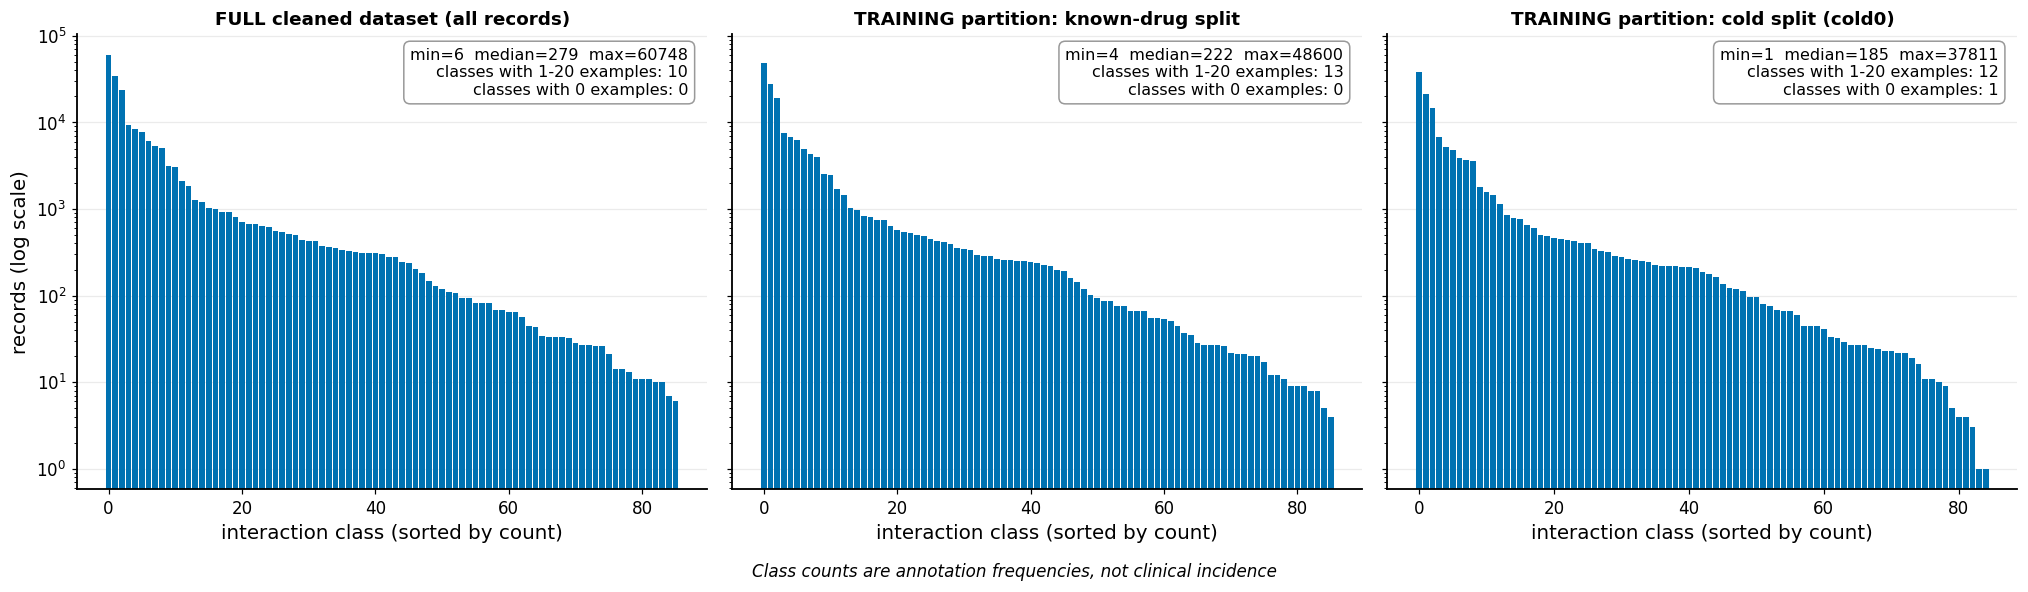

In [ ]:
def plot_class_counts(panels, stem):
    fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 5.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (title, counts) in zip(axes, panels):
        pos = np.sort(counts[counts > 0])[::-1]
        ax.bar(np.arange(len(pos)), pos, color=POSTER_COLORS['blue'], width=0.85)
        ax.set_yscale('log'); ax.set_xlabel('interaction class (sorted by count)'); ax.set_title(title, fontsize=12)
        txt = (f'min={pos.min()}  median={np.median(pos):.0f}  max={pos.max()}\n'
               f'classes with 1-20 examples: {int(((counts > 0) & (counts <= 20)).sum())}\n'
               f'classes with 0 examples: {int((counts == 0).sum())}')
        ax.text(0.97, 0.97, txt, transform=ax.transAxes, ha='right', va='top', fontsize=10.5,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.6'))
    axes[0].set_ylabel('records (log scale)')
    fig.text(0.5, 0.0, 'Class counts are annotation frequencies, not clinical incidence', ha='center', va='top', fontsize=11, style='italic')
    fig.tight_layout()
    data = pd.DataFrame({'class_idx': np.arange(len(panels[0][1]))})            # numbers behind the figure, one column per panel
    for title, counts in panels:
        data[title] = counts
    save_fig(fig, stem, data)

plot_class_counts([
    ('FULL cleaned dataset (all records)', full_counts),
    ('TRAINING partition: known-drug split', class_counts(DF_Y[SPLITS['known']['train']], K)),
    (f'TRAINING partition: cold split ({DEV})', class_counts(DF_Y[SPLITS[DEV]['train']], K)),
], 'class_counts_log')


## 4. Library: metrics, class weights, models, training

Nothing in this section trains anything by itself; it defines the tools used later.

- **Zero-training-class policy:** logits of classes with no training example are masked to -1e9 in training and at inference, so they are never predicted. They stay in the 86-label denominator and appear in their own tail bin.
- **Class weights** use training counts only. `sqrt`: proportional to 1/sqrt(n_c), capped at `SQRT_WEIGHT_CAP` times the median supported-class weight, then renormalised so the average weight over training samples is 1. `effnum`: (1-beta)/(1-beta^n_c). Absent classes get weight 0.
- **Post-hoc logit adjustment** applies only to an unweighted model: `logit - tau * log(prior)`, with tau chosen on validation. It is never combined with weighting.
- The shared-encoder and GNN models embed **all** drugs each step, but only training pairs contribute to the loss, so unseen drugs never receive gradient.

### 4.1 Metrics, weights, bootstrap helpers

In [ ]:
def macro_stats(y, pred, K):
    tp = np.bincount(y[pred == y], minlength=K).astype(np.float64)
    true = np.bincount(y, minlength=K).astype(np.float64)
    pc = np.bincount(pred, minlength=K).astype(np.float64)
    prec = tp / np.maximum(pc, 1); rec = tp / np.maximum(true, 1); f1 = 2 * tp / np.maximum(pc + true, 1)   # 0 when undefined
    return tp, true, pc, prec, rec, f1

def topk_acc(scores, y, k):
    k = min(k, scores.shape[1])
    idx = np.argpartition(-scores, k - 1, axis=1)[:, :k]
    return float((idx == y[:, None]).any(1).mean())

def evaluate_scores(scores, y, K, with_topk=True):
    if len(y) == 0:
        return None
    pred = scores.argmax(1)
    tp, true, pc, prec, rec, f1 = macro_stats(y, pred, K)
    sup = true > 0
    out = dict(n=int(len(y)), accuracy=float((pred == y).mean()),
               macro_f1_all=float(f1.mean()),                       # denominator = all K labels
               macro_f1_supported=float(f1[sup].mean()),            # denominator = labels with test support
               macro_recall_supported=float(rec[sup].mean()), macro_precision_supported=float(prec[sup].mean()),
               n_supported_labels=int(sup.sum()), n_predicted_labels=int((pc > 0).sum()))
    if with_topk:
        out['top3'] = topk_acc(scores, y, 3); out['top5'] = topk_acc(scores, y, 5)
    return out

def tail_metrics(y, pred, train_counts, bins, K):
    tp, true, pc, prec, rec, f1 = macro_stats(y, pred, K)
    n = len(y); out = []
    defs = [('0 (absent from train)', 0, 0)] + [((f'{lo}-{hi}' if hi < 10**8 else f'>{lo - 1}'), lo, hi) for lo, hi in bins]
    for name, lo, hi in defs:
        labs = np.where((train_counts >= lo) & (train_counts <= hi))[0]
        sup = labs[true[labs] > 0]; nt = true[labs].sum()
        out.append(dict(bin=name, n_classes=len(labs), n_classes_with_test_support=len(sup), n_test=int(nt),
                        true_share=float(nt / n), pred_share=float(pc[labs].sum() / n),
                        macro_f1=float(f1[sup].mean()) if len(sup) else np.nan,
                        macro_recall=float(rec[sup].mean()) if len(sup) else np.nan,
                        macro_precision=float(prec[sup].mean()) if len(sup) else np.nan,
                        micro_recall=float(tp[labs].sum() / nt) if nt > 0 else np.nan))
    return out

def class_weights(counts, scheme):
    n = counts.astype(np.float64); sup = n > 0; w = np.zeros_like(n)
    if scheme == 'none':
        w[sup] = 1.0
    elif scheme == 'sqrt':
        w[sup] = 1.0 / np.sqrt(n[sup])
        cap = CFG['SQRT_WEIGHT_CAP']
        if cap: w[sup] = np.minimum(w[sup], cap * np.median(w[sup]))
    elif scheme == 'effnum':
        w[sup] = (1 - CFG['EFF_BETA']) / (1 - CFG['EFF_BETA'] ** n[sup])
    else:
        raise ValueError(scheme)
    w[sup] *= n[sup].sum() / (w[sup] * n[sup]).sum()             # mean weight over training samples = 1
    return w.astype(np.float32)

def posthoc_adjust(logits, train_counts, tau):
    prior = train_counts / train_counts.sum()
    lp = np.where(train_counts > 0, np.log(np.maximum(prior, 1e-12)), 0.0).astype(np.float32)
    return logits - tau * lp[None, :]                            # masked classes (-1e9) stay masked

def mask_vector(counts):
    return np.where(counts > 0, 0.0, -1e9).astype(np.float32)

def cluster_matrices(y, pred, cluster, k=None):
    """Per-cluster counts: truth[g, c], predicted[g, c], true-positive[g, c]."""
    k = K if k is None else k
    uniq, inv = np.unique(cluster, return_inverse=True); G = len(uniq)
    truth, predc, tp = np.zeros((G, k)), np.zeros((G, k)), np.zeros((G, k))
    np.add.at(truth, (inv, y), 1); np.add.at(predc, (inv, pred), 1)
    ok = y == pred; np.add.at(tp, (inv[ok], y[ok]), 1)
    return truth, predc, tp

def f1_from_counts(TP, PC, TR, classes):
    """Macro-F1 over `classes` from (n x K) count arrays; each row is one bootstrap draw (or the observed sample)."""
    return (2 * TP[:, classes] / np.maximum(PC[:, classes] + TR[:, classes], 1)).mean(axis=1)

### 4.2 Models

In [ ]:
def pair_features(fa, fb):
    assert fa.dtype == torch.float32 and fb.dtype == torch.float32, 'pair features must be float (signed difference)'
    return torch.cat([fa, fb, fa - fb, fa * fb], dim=1)          # ordered: A, B, signed A-B, A*B

def mlp_head(inp, hidden, K, drop):
    return nn.Sequential(nn.Linear(inp, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(drop), nn.Linear(hidden, K))

class PairMLP(nn.Module):                     # candidate 2: ordered fingerprint MLP
    def __init__(self, fp, K, hidden=1024, drop=0.3):
        super().__init__(); self.register_buffer('fp', fp.float()); d = fp.shape[1]
        self.net = nn.Sequential(nn.Linear(4 * d, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(drop),
                                 nn.Linear(hidden, hidden // 2), nn.LayerNorm(hidden // 2), nn.ReLU(), nn.Dropout(drop),
                                 nn.Linear(hidden // 2, K))
    def embed_all(self): return self.fp
    def pair_logits(self, Z, a, b): return self.net(pair_features(Z[a], Z[b]))
    def forward(self, a, b): return self.pair_logits(self.embed_all(), a, b)

class SharedEncPair(nn.Module):               # candidate 3 (and 5 with transformer features): shared encoder + role-sensitive pair head
    def __init__(self, feat, K, dim=256, hidden=512, drop=0.3):
        super().__init__(); self.register_buffer('feat', feat.float()); d = feat.shape[1]
        self.enc = nn.Sequential(nn.Linear(d, 512), nn.LayerNorm(512), nn.ReLU(), nn.Dropout(drop),
                                 nn.Linear(512, dim), nn.LayerNorm(dim), nn.ReLU())
        self.head = mlp_head(4 * dim, hidden, K, drop)
    def embed_all(self): return self.enc(self.feat)
    def pair_logits(self, Z, a, b): return self.head(pair_features(Z[a], Z[b]))
    def forward(self, a, b): return self.pair_logits(self.embed_all(), a, b)

class GNNLayer(nn.Module):
    def __init__(self, w, ed):
        super().__init__()
        self.msg = nn.Sequential(nn.Linear(w + ed, w), nn.ReLU())
        self.upd = nn.Linear(2 * w, w); self.norm = nn.LayerNorm(w)
    def forward(self, h, src, dst, ea):
        m = self.msg(torch.cat([h[src], ea], dim=1))
        agg = torch.zeros_like(h).index_add_(0, dst, m)
        return h + F.relu(self.norm(self.upd(torch.cat([h, agg], dim=1))))

class GNNPair(nn.Module):                     # candidate 4: small bond-aware GNN + fingerprint residual + role-sensitive head
    def __init__(self, graph, fp, K, width=128, layers=3, dim=256, hidden=512, drop=0.3):
        super().__init__()
        for k in ['x', 'src', 'dst', 'edge_attr', 'batch']:
            self.register_buffer(k, graph[k])
        self.register_buffer('fp', fp.float()); self.n_drugs = graph['n_drugs']
        self.register_buffer('cnt', torch.bincount(graph['batch'], minlength=self.n_drugs).clamp(min=1).float())
        self.atom_in = nn.Linear(graph['x'].shape[1], width)
        self.layers = nn.ModuleList([GNNLayer(width, graph['edge_attr'].shape[1]) for _ in range(layers)])
        self.read = nn.Linear(2 * width, dim); self.fp_proj = nn.Linear(fp.shape[1], dim)
        self.post = nn.Sequential(nn.LayerNorm(dim), nn.ReLU(), nn.Dropout(drop))
        self.head = mlp_head(4 * dim, hidden, K, drop)
    def embed_all(self):
        h = F.relu(self.atom_in(self.x))
        for l in self.layers:
            h = l(h, self.src, self.dst, self.edge_attr)
        mean = torch.zeros(self.n_drugs, h.shape[1], device=h.device).index_add_(0, self.batch, h) / self.cnt[:, None]
        mx = torch.zeros(self.n_drugs, h.shape[1], device=h.device).scatter_reduce(
            0, self.batch[:, None].expand_as(h), h, reduce='amax', include_self=False)
        return self.post(self.read(torch.cat([mean, mx], dim=1)) + self.fp_proj(self.fp))
    def pair_logits(self, Z, a, b): return self.head(pair_features(Z[a], Z[b]))
    def forward(self, a, b): return self.pair_logits(self.embed_all(), a, b)

### 4.3 Frozen transformer features and model factory

In [ ]:
def transformer_embeddings():
    path = OUT / 'features' / ('emb_' + CFG['TRANSFORMER_ID'].replace('/', '_') + '.npy')
    if path.exists():
        return np.load(path)
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(CFG['TRANSFORMER_ID'])
    mdl = AutoModel.from_pretrained(CFG['TRANSFORMER_ID']).to(DEVICE).eval()
    n_trunc = sum(len(tok(s)['input_ids']) > 256 for s in CANON)
    embs = []
    with torch.no_grad():
        for i in range(0, len(CANON), 64):
            enc = tok(CANON[i:i + 64], padding=True, truncation=True, max_length=256, return_tensors='pt').to(DEVICE)
            h = mdl(**enc).last_hidden_state; m = enc['attention_mask'].unsqueeze(-1).float()
            embs.append(((h * m).sum(1) / m.sum(1)).cpu().numpy())
    E = np.concatenate(embs).astype(np.float32); np.save(path, E)
    json.dump(dict(checkpoint=CFG['TRANSFORMER_ID'], dim=int(E.shape[1]), n_truncated_at_256_tokens=int(n_trunc),
                   note='Frozen encoder, mean-pooled. Record the checkpoint pretraining corpus in the poster; exposure to DrugBank molecules is possible.'),
              open(OUT / 'features' / 'transformer_meta.json', 'w'), indent=1)
    return E

def build_model(name, split_key):
    fp = torch.tensor(FP_NP)
    if name == 'mlp': m = PairMLP(fp, K)
    elif name == 'sharedenc': m = SharedEncPair(fp, K)
    elif name == 'gnn': m = GNNPair(GRAPH, fp, K)
    elif name == 'transformer':
        E = transformer_embeddings(); sp = SPLITS[split_key]
        tr_drugs = np.unique(np.concatenate([DF_A[sp['train']], DF_B[sp['train']]]))
        mu, sd = E[tr_drugs].mean(0), E[tr_drugs].std(0) + 1e-6           # standardisation fitted on training drugs only
        m = SharedEncPair(torch.cat([fp.float(), torch.tensor((E - mu) / sd, dtype=torch.float32)], dim=1), K)
    else: raise ValueError(name)
    return m.to(DEVICE)

### 4.4 Training and prediction
All runs are **resumable and cached**: a finished run is skipped, and an interrupted neural run resumes from its last epoch.

**Early stopping:** neural models stop on validation macro-F1 over all 86 labels (patience `PATIENCE`). XGBoost is trained on ordered fingerprints (`fp_A` then `fp_B`) with a multiclass soft-probability objective and stops on validation log-loss (patience `XGB_EARLY`, at most `XGB_ROUNDS` rounds).

In [ ]:
def run_dir(split_key, model_name, weighting):
    d = OUT / 'runs' / f'{split_key}__{model_name}__{weighting}'; d.mkdir(parents=True, exist_ok=True); return d

def get_result(split_key, model_name, weighting):
    p = run_dir(split_key, model_name, weighting) / 'result.json'
    return json.load(open(p)) if p.exists() else None

def capped_train_rows(sp):
    tr = sp['train']; cap = CFG['TRAIN_CAP']
    return np.random.RandomState(0).choice(tr, cap, replace=False) if cap and len(tr) > cap else tr

def _t(rows):
    return (torch.tensor(DF_A[rows], device=DEVICE), torch.tensor(DF_B[rows], device=DEVICE), torch.tensor(DF_Y[rows], device=DEVICE))

@torch.no_grad()
def neural_logits(model, a, b, mask, bs=8192):
    model.eval(); Z = model.embed_all()
    return torch.cat([model.pair_logits(Z, a[i:i + bs], b[i:i + bs]) + mask for i in range(0, len(a), bs)])

def train_neural(model_name, split_key, weighting='none'):
    rd = run_dir(split_key, model_name, weighting)
    if (rd / 'result.json').exists():
        return json.load(open(rd / 'result.json'))
    seed_everything(CFG['SEED']); sp = SPLITS[split_key]; tr = capped_train_rows(sp)
    counts = class_counts(DF_Y[tr], K); np.save(rd / 'train_counts.npy', counts)
    wt = torch.tensor(class_weights(counts, weighting), device=DEVICE)
    mask = torch.tensor(mask_vector(counts), device=DEVICE)
    a_tr, b_tr, y_tr = _t(tr); a_va, b_va, _ = _t(sp['val']); y_va = DF_Y[sp['val']]
    model = build_model(model_name, split_key)
    n_params = sum(p.numel() for p in model.parameters())
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['LR'], weight_decay=CFG['WD'])
    state = dict(epoch=0, best=-1.0, best_epoch=0, bad=0, hist=[])
    ck = rd / 'ckpt_last.pt'
    if ck.exists():                                                   # resume after a disconnect
        c = torch.load(ck, map_location=DEVICE, weights_only=False)
        model.load_state_dict(c['model']); opt.load_state_dict(c['opt']); state = c['state']
        print(f'resuming {rd.name} from epoch {state["epoch"]}')
    if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats()
    bs = CFG['BATCH']
    while state['epoch'] < CFG['MAX_EPOCHS'] and state['bad'] < CFG['PATIENCE']:
        te = time.time(); model.train()
        perm = torch.randperm(len(tr), device=DEVICE); tot, nb = 0.0, 0
        for i in range(0, len(tr), bs):
            idx = perm[i:i + bs]
            loss = F.cross_entropy(model(a_tr[idx], b_tr[idx]) + mask, y_tr[idx], weight=wt)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
            tot += float(loss); nb += 1
        m = evaluate_scores(neural_logits(model, a_va, b_va, mask).cpu().numpy(), y_va, K, with_topk=False)
        sel = m[CFG['SELECT_METRIC']]; state['epoch'] += 1; improved = sel > state['best']
        if sel > state['best']:
            state.update(best=sel, best_epoch=state['epoch'], bad=0); torch.save(model.state_dict(), rd / 'best.pt')
        else:
            state['bad'] += 1
        state['hist'].append(dict(epoch=state['epoch'], loss=tot / nb, val_macro_f1_all=m['macro_f1_all'], val_acc=m['accuracy'], sec=time.time() - te))
        torch.save(dict(model=model.state_dict(), opt=opt.state_dict(), state=state), ck)
        if improved or state['epoch'] % CFG['PRINT_EVERY'] == 0:
            print(f"[{rd.name}] ep {state['epoch']:02d} loss {tot / nb:.4f} val macroF1(86) {m['macro_f1_all']:.4f} acc {m['accuracy']:.4f} ({time.time() - te:.1f}s)")
    model.load_state_dict(torch.load(rd / 'best.pt', map_location=DEVICE))
    lg = neural_logits(model, a_va, b_va, mask).cpu().numpy(); np.save(rd / 'val_logits.npy', lg)
    vm = evaluate_scores(lg, y_va, K)
    secs = [h['sec'] for h in state['hist']]
    res = dict(split=split_key, model=model_name, weighting=weighting, n_params=int(n_params), best_epoch=state['best_epoch'],
               epochs_run=state['epoch'], train_sec=float(sum(secs)), sec_per_epoch=float(np.mean(secs)) if secs else None,
               peak_gpu_mb=(torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == 'cuda' else None),
               peak_rss_mb=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, **{f'val_{k}': v for k, v in vm.items()})
    json.dump(res, open(rd / 'result.json', 'w'), indent=1)
    return res

def _xgb_matrix(rows):
    return sps.hstack([FP_CSR[DF_A[rows]], FP_CSR[DF_B[rows]]], format='csr')     # ordered: fp_A | fp_B

def train_xgb(split_key, weighting='none'):
    import xgboost as xgb
    rd = run_dir(split_key, 'xgb', weighting)
    if (rd / 'result.json').exists():
        return json.load(open(rd / 'result.json'))
    sp = SPLITS[split_key]; tr = capped_train_rows(sp)
    counts = class_counts(DF_Y[tr], K); np.save(rd / 'train_counts.npy', counts)
    sw = class_weights(counts, weighting)[DF_Y[tr]] if weighting != 'none' else None
    dtr = xgb.DMatrix(_xgb_matrix(tr), label=DF_Y[tr], weight=sw)
    dva = xgb.DMatrix(_xgb_matrix(sp['val']), label=DF_Y[sp['val']])
    params = dict(objective='multi:softprob', num_class=K, eval_metric='mlogloss', max_depth=CFG['XGB_DEPTH'], eta=CFG['XGB_LR'],
                  subsample=0.8, colsample_bytree=0.5, tree_method='hist', device='cuda' if DEVICE.type == 'cuda' else 'cpu', seed=CFG['SEED'])
    params["base_score"] = 0.5  # Disable automatic intercept estimation

    t0 = time.time()
    bst = xgb.train(params, dtr, num_boost_round=CFG['XGB_ROUNDS'], evals=[(dva, 'val')],
                    early_stopping_rounds=CFG['XGB_EARLY'], verbose_eval=20)
    sec = time.time() - t0; best_it = int(bst.best_iteration)
    bst.save_model(str(rd / 'model.json'))
    prob = bst.predict(dva, iteration_range=(0, best_it + 1))
    lg = (np.log(np.maximum(prob, 1e-12)) + mask_vector(counts)[None, :]).astype(np.float32); np.save(rd / 'val_logits.npy', lg)
    vm = evaluate_scores(lg, DF_Y[sp['val']], K)
    res = dict(split=split_key, model='xgb', weighting=weighting, n_params=None, best_epoch=best_it + 1, epochs_run=best_it + 1 + CFG['XGB_EARLY'],
               train_sec=sec, sec_per_epoch=sec / max(best_it + 1, 1), peak_gpu_mb=None,
               peak_rss_mb=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, best_iteration=best_it,
               **{f'val_{k}': v for k, v in vm.items()})
    json.dump(res, open(rd / 'result.json', 'w'), indent=1)
    return res

def train_entry(model_name, split_key, weighting):
    return train_xgb(split_key, weighting) if model_name == 'xgb' else train_neural(model_name, split_key, weighting)

def predict_logits(model_name, split_key, weighting, rows):
    """Masked logits (xgb: log-probabilities) for arbitrary rows, from the saved best model of that run."""
    rd = run_dir(split_key, model_name, weighting); counts = np.load(rd / 'train_counts.npy')
    if model_name == 'xgb':
        import xgboost as xgb
        bst = xgb.Booster(); bst.load_model(str(rd / 'model.json'))
        prob = bst.predict(xgb.DMatrix(_xgb_matrix(rows)), iteration_range=(0, json.load(open(rd / 'result.json'))['best_iteration'] + 1))
        return (np.log(np.maximum(prob, 1e-12)) + mask_vector(counts)[None, :]).astype(np.float32)
    model = build_model(model_name, split_key); model.load_state_dict(torch.load(rd / 'best.pt', map_location=DEVICE))
    a, b, _ = _t(rows)
    return neural_logits(model, a, b, torch.tensor(mask_vector(counts), device=DEVICE)).cpu().numpy()

def select_tau(split_key, model_name, weighting='none'):
    """Choose tau on this split's validation logits (unweighted model)."""
    rd = run_dir(split_key, model_name, weighting); counts = np.load(rd / 'train_counts.npy'); lg = np.load(rd / 'val_logits.npy')
    y = DF_Y[SPLITS[split_key]['val']]; sc = {}
    for tau in CFG['TAU_GRID']:
        sc[tau] = evaluate_scores(posthoc_adjust(lg, counts, tau), y, K, with_topk=False)[CFG['SELECT_METRIC']]
    best = max(sc, key=sc.get)
    return best, sc

def results_table(items):
    rs = [get_result(*i) for i in items]
    rs = [r for r in rs if r]
    cols = ['split', 'model', 'weighting', 'val_macro_f1_all', 'val_macro_f1_supported', 'val_accuracy', 'val_macro_recall_supported',
            'val_top3', 'val_top5', 'best_epoch', 'sec_per_epoch', 'train_sec', 'n_params', 'peak_gpu_mb']
    return pd.DataFrame(rs)[cols].round(4) if rs else pd.DataFrame()

## 5. Self-test on synthetic data (seconds)

Checks split assertions (including identity groups), weight properties, signed pair features, model output shapes, finite losses, metric denominators and the bootstrap helpers, all on toy data. It does not touch the real splits. **If this cell fails, fix that before running anything expensive.**

In [ ]:
def smoke_synthetic():
    rng = np.random.RandomState(0); nd, Ks = 60, 8
    pr = []
    for _ in range(1500):
        u, v = rng.choice(nd, 2, replace=False); y = int(min(rng.geometric(0.4) - 1, Ks - 1)); pr.append((u, v, y))
        if rng.rand() < 0.5: pr.append((v, u, y))
    sdf = pd.DataFrame(pr, columns=['a', 'b', 'y']).drop_duplicates(['a', 'b']).reset_index(drop=True)
    sdf['pair_id'] = pair_ids(sdf)

    # Splits, including two "twin" drug pairs that must always share a role
    ks = make_known_split(sdf, Ks, 0); check_known_split(sdf, ks)
    grp = np.arange(nd); grp[11] = grp[10]; grp[13] = grp[12]
    cs = make_cold_split(sdf, grp, 0, 0.1, 0.1); check_cold_split(sdf, cs)
    assert cs['role'][10] == cs['role'][11] and cs['role'][12] == cs['role'][13], 'twins were split apart'
    assert len(cs['tests']['one_unseen']) > 0 and len(cs['val']) > 0

    # Identity keys: stereoisomers and salts must collapse, different molecules must not
    assert identity_key(Chem.MolFromSmiles('C[C@H](N)C(=O)O')) == identity_key(Chem.MolFromSmiles('C[C@@H](N)C(=O)O'))
    assert identity_key(Chem.MolFromSmiles('CC(=O)[O-].[Na+]')) == identity_key(Chem.MolFromSmiles('CC(=O)O'))
    assert identity_key(Chem.MolFromSmiles('CCO')) != identity_key(Chem.MolFromSmiles('CCN'))

    # Class weights
    cnt = np.array([0, 4, 100, 5000, 48000, 20, 1000, 7])
    for sch in ['none', 'sqrt', 'effnum']:
        w = class_weights(cnt, sch)
        assert w[0] == 0 and (w[1:] > 0).all() and np.isfinite(w).all()
        assert abs((w * cnt).sum() / cnt.sum() - 1) < 1e-4, sch
    w = class_weights(cnt, 'sqrt'); sup = cnt > 0
    assert w.max() / np.median(w[sup]) <= CFG['SQRT_WEIGHT_CAP'] * (1 + 1e-4) + 1e-6

    # Signed features (uint8 subtraction must not wrap)
    fa = torch.tensor(np.array([[0, 1]], dtype=np.uint8)).float(); fb = torch.tensor(np.array([[1, 0]], dtype=np.uint8)).float()
    pf = pair_features(fa, fb); assert pf[0, 4:6].tolist() == [-1.0, 1.0], pf

    # Models: shapes, finite loss, backward
    fp = torch.tensor(rng.randint(0, 2, (nd, 64)).astype(np.float32))
    smi = ['CCO', 'c1ccccc1', 'CC(=O)O', 'CCN(CC)CC', 'c1ccncc1', 'C1CCCCC1', 'CC(C)Cc1ccc(cc1)C(C)C(=O)O', 'OC(=O)c1ccccc1O']
    g = build_graph([Chem.MolFromSmiles(smi[i % len(smi)]) for i in range(nd)])
    a = torch.tensor(rng.randint(0, nd, 32)); b = torch.tensor(rng.randint(0, nd, 32)); y = torch.tensor(rng.randint(0, Ks, 32))
    wt = torch.tensor(class_weights(np.bincount(rng.randint(1, Ks, 500), minlength=Ks), 'sqrt'))
    for mdl in [PairMLP(fp, Ks, hidden=64), SharedEncPair(fp, Ks, dim=32, hidden=64), GNNPair(g, fp, Ks, width=16, layers=2, dim=32, hidden=64)]:
        mdl.train(); out = mdl(a, b); assert out.shape == (32, Ks)
        loss = F.cross_entropy(out, y, weight=wt); assert torch.isfinite(loss); loss.backward()

    # Metrics + post-hoc adjustment
    sc = rng.randn(200, Ks).astype(np.float32); yy = rng.randint(0, Ks - 2, 200)
    m = evaluate_scores(sc, yy, Ks)
    assert 0 <= m['accuracy'] <= 1 and m['macro_f1_all'] <= m['macro_f1_supported'] + 1e-9 and m['n_supported_labels'] == Ks - 2
    assert posthoc_adjust(sc, cnt, 0.5).shape == sc.shape
    tm = tail_metrics(yy, sc.argmax(1), cnt, CFG['TAIL_BINS'], Ks); assert len(tm) == 4

    # Bootstrap helpers: perfect predictions give F1 = 1 on present classes; identical models give a zero difference
    yb = rng.randint(0, Ks, 300); cl = rng.randint(0, 20, 300)
    t, p_, tp_ = cluster_matrices(yb, yb.copy(), cl, k=Ks)
    assert t.sum() == 300 and (tp_ == t).all() and (p_ == t).all()
    present = np.where(t.sum(0) > 0)[0]
    assert np.allclose(f1_from_counts(tp_.sum(0, keepdims=True), p_.sum(0, keepdims=True), t.sum(0, keepdims=True), present), 1.0)
    W = rng.multinomial(20, np.ones(20) / 20, size=5).astype(float)
    assert np.allclose(f1_from_counts(W @ tp_, W @ p_, W @ t, present) - f1_from_counts(W @ tp_, W @ p_, W @ t, present), 0)
    print('SELF-TEST OK: splits (with twins), identity keys, weights, signed features, model shapes/losses, metrics, bootstrap helpers')

smoke_synthetic()

SELF-TEST OK: splits (with twins), identity keys, weights, signed features, model shapes/losses, metrics, bootstrap helpers


## 6. Train the five candidates on the development partition

All five use ordinary (unweighted) cross-entropy here, so the architecture comparison is fair. Selection uses **one-unseen-drug validation** macro-F1 over all 86 labels. Test rows are not touched.

| Candidate | What it is |
|---|---|
| `xgb` | XGBoost on ordered fingerprints (`fp_A` then `fp_B`), the strong classical baseline |
| `mlp` | Ordered fingerprint MLP (A, B, A-B, A*B) |
| `sharedenc` | Shared molecule encoder, then an order-aware pair head |
| `gnn` | Small bond-aware graph network plus a fingerprint shortcut |
| `transformer` | Frozen ChemBERTa embeddings plus fingerprints, then the shared-encoder head |

### 6.1 Time one epoch first
The cheapest neural model runs first so you can judge the remaining budget.

In [ ]:
r_mlp = attempt('dev: mlp', train_neural, 'mlp', DEV, 'none')
if r_mlp:
    print(f"ordered MLP: {r_mlp['sec_per_epoch']:.1f} s/epoch, {r_mlp['epochs_run']} epochs run, best epoch {r_mlp['best_epoch']}")

[cold0__mlp__none] ep 01 loss 0.9265 val macroF1(86) 0.4793 acc 0.7036 (1.5s)
[cold0__mlp__none] ep 02 loss 0.2999 val macroF1(86) 0.5799 acc 0.7293 (1.5s)
[cold0__mlp__none] ep 03 loss 0.2094 val macroF1(86) 0.6220 acc 0.7365 (1.5s)
[cold0__mlp__none] ep 04 loss 0.1591 val macroF1(86) 0.6227 acc 0.7356 (1.2s)
[cold0__mlp__none] ep 05 loss 0.1352 val macroF1(86) 0.6266 acc 0.7424 (1.2s)
[cold0__mlp__none] ep 06 loss 0.1166 val macroF1(86) 0.6381 acc 0.7413 (1.2s)
[cold0__mlp__none] ep 10 loss 0.0742 val macroF1(86) 0.6418 acc 0.7484 (1.2s)
[cold0__mlp__none] ep 12 loss 0.0628 val macroF1(86) 0.6467 acc 0.7468 (1.2s)
[cold0__mlp__none] ep 13 loss 0.0596 val macroF1(86) 0.6490 acc 0.7445 (1.2s)
[cold0__mlp__none] ep 15 loss 0.0548 val macroF1(86) 0.6318 acc 0.7515 (1.1s)
ordered MLP: 1.0 s/epoch, 18 epochs run, best epoch 13


### 6.2 Shared encoder and XGBoost

In [ ]:
attempt('dev: sharedenc', train_neural, 'sharedenc', DEV, 'none')
attempt('dev: xgb', train_xgb, DEV, 'none')
tbl3 = results_table([(DEV, 'xgb', 'none'), (DEV, 'mlp', 'none'), (DEV, 'sharedenc', 'none')])
tbl3.to_csv(OUT / 'tables' / 'dev_architecture_xgb_mlp_sharedenc.csv', index=False)
show(tbl3)

[cold0__sharedenc__none] ep 01 loss 1.0208 val macroF1(86) 0.4672 acc 0.7211 (0.6s)
[cold0__sharedenc__none] ep 02 loss 0.3091 val macroF1(86) 0.6027 acc 0.7290 (0.6s)
[cold0__sharedenc__none] ep 03 loss 0.2187 val macroF1(86) 0.6293 acc 0.7355 (0.6s)
[cold0__sharedenc__none] ep 05 loss 0.1503 val macroF1(86) 0.6257 acc 0.7383 (0.5s)
[cold0__sharedenc__none] ep 07 loss 0.1155 val macroF1(86) 0.6424 acc 0.7470 (0.6s)
[cold0__sharedenc__none] ep 10 loss 0.0880 val macroF1(86) 0.6255 acc 0.7412 (0.5s)
[0]	val-mlogloss:3.20947
[20]	val-mlogloss:1.49470
[40]	val-mlogloss:1.19358
[60]	val-mlogloss:1.08209
[80]	val-mlogloss:1.03593
[100]	val-mlogloss:1.00872
[120]	val-mlogloss:0.98986
[140]	val-mlogloss:0.97571
[160]	val-mlogloss:0.96781
[180]	val-mlogloss:0.95846
[200]	val-mlogloss:0.95063
[220]	val-mlogloss:0.94537
[240]	val-mlogloss:0.94147
[260]	val-mlogloss:0.93659
[280]	val-mlogloss:0.93178
[299]	val-mlogloss:0.93058


,split,model,weighting,val F1 (all 86),val F1 (supported),val accuracy,val recall (supported),val top-3,val top-5,best epoch,sec / epoch,train sec,# params,peak GPU MB
0,cold0,xgb,none,0.620,0.651,0.723,0.631,0.920,0.959,300,0.352,105.705,NaN,NaN
1,cold0,mlp,none,0.649,0.681,0.744,0.689,0.928,0.959,13,1.006,18.112,4767318.0,362.434
2,cold0,sharedenc,none,0.642,0.674,0.747,0.703,0.921,0.953,7,0.472,5.665,1227606.0,118.820


### 6.3 Optional candidates: GNN and frozen transformer
Switch them off with `RUN_GNN` / `RUN_TRANSFORMER` in section 0.2 if time is short. If one crashes, it is logged and the notebook continues.

In [ ]:
if CFG['RUN_GNN']:         attempt('dev: gnn', train_neural, 'gnn', DEV, 'none')
if CFG['RUN_TRANSFORMER']: attempt('dev: transformer', train_neural, 'transformer', DEV, 'none')

tbl = results_table([(DEV, m, 'none') for m in ['xgb', 'mlp', 'sharedenc', 'gnn', 'transformer']])
tbl.to_csv(OUT / 'tables' / 'dev_architecture_comparison.csv', index=False)
print('=== DEVELOPMENT ARCHITECTURE COMPARISON (validation, no test rows) ===')
show(tbl)
if len(tbl):
    best = tbl.sort_values('val_macro_f1_all', ascending=False).iloc[0]
    print(f"\nBest validation F1 (86 labels): {best['model']} at {best['val_macro_f1_all']:.3f}. "
          "Gaps of about 0.01-0.02 between models are within epoch-to-epoch noise; do not read a ranking into them.")

[cold0__gnn__none] ep 01 loss 1.8401 val macroF1(86) 0.3097 acc 0.6865 (5.7s)
[cold0__gnn__none] ep 02 loss 0.5527 val macroF1(86) 0.5169 acc 0.7218 (5.7s)
[cold0__gnn__none] ep 03 loss 0.3672 val macroF1(86) 0.5948 acc 0.7264 (5.7s)
[cold0__gnn__none] ep 04 loss 0.2899 val macroF1(86) 0.6187 acc 0.7419 (5.8s)
[cold0__gnn__none] ep 05 loss 0.2478 val macroF1(86) 0.6339 acc 0.7416 (5.8s)
[cold0__gnn__none] ep 06 loss 0.2205 val macroF1(86) 0.6476 acc 0.7401 (5.8s)
[cold0__gnn__none] ep 07 loss 0.1990 val macroF1(86) 0.6512 acc 0.7536 (5.7s)
[cold0__gnn__none] ep 09 loss 0.1682 val macroF1(86) 0.6601 acc 0.7580 (5.8s)
[cold0__gnn__none] ep 10 loss 0.1597 val macroF1(86) 0.6498 acc 0.7511 (5.7s)
[cold0__gnn__none] ep 14 loss 0.1286 val macroF1(86) 0.6634 acc 0.7495 (5.8s)
[cold0__gnn__none] ep 15 loss 0.1242 val macroF1(86) 0.6428 acc 0.7511 (5.6s)


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Token indices sequence length is longer than the specified maximum sequence length for this model (645 > 512). Running

[cold0__transformer__none] ep 01 loss 1.1067 val macroF1(86) 0.4144 acc 0.7221 (0.6s)
[cold0__transformer__none] ep 02 loss 0.3675 val macroF1(86) 0.5897 acc 0.7302 (0.7s)
[cold0__transformer__none] ep 03 loss 0.2547 val macroF1(86) 0.5997 acc 0.7264 (0.6s)
[cold0__transformer__none] ep 05 loss 0.1731 val macroF1(86) 0.5979 acc 0.7465 (0.6s)
[cold0__transformer__none] ep 07 loss 0.1372 val macroF1(86) 0.6201 acc 0.7523 (0.7s)
[cold0__transformer__none] ep 10 loss 0.1063 val macroF1(86) 0.6328 acc 0.7412 (0.7s)
[cold0__transformer__none] ep 11 loss 0.0984 val macroF1(86) 0.6340 acc 0.7482 (1.0s)
[cold0__transformer__none] ep 15 loss 0.0771 val macroF1(86) 0.6228 acc 0.7344 (0.6s)
=== DEVELOPMENT ARCHITECTURE COMPARISON (validation, no test rows) ===


,split,model,weighting,val F1 (all 86),val F1 (supported),val accuracy,val recall (supported),val top-3,val top-5,best epoch,sec / epoch,train sec,# params,peak GPU MB
0,cold0,xgb,none,0.620,0.651,0.723,0.631,0.920,0.959,300,0.352,105.705,NaN,NaN
1,cold0,mlp,none,0.649,0.681,0.744,0.689,0.928,0.959,13,1.006,18.112,4767318.0,362.434
2,cold0,sharedenc,none,0.642,0.674,0.747,0.703,0.921,0.953,7,0.472,5.665,1227606.0,118.820
3,cold0,gnn,none,0.663,0.696,0.750,0.732,0.929,0.960,14,5.592,106.245,1055318.0,782.326
4,cold0,transformer,none,0.634,0.665,0.748,0.688,0.906,0.940,11,0.573,9.172,1424214.0,125.490



Best validation F1 (86 labels): gnn at 0.663. Gaps of about 0.01-0.02 between models are within epoch-to-epoch noise; do not read a ranking into them.


## 7. XGBoost across all partitions (validation only)

The baseline is trained on every drug partition so that its behaviour can be compared across partitions before any test row is used. The table reports the boosting round kept by early stopping, the validation F1 and the number of interaction types absent from training in each partition.

In [ ]:
rows = []
for s in CFG['COLD_SEEDS']:
    sk = f'cold{s}'
    r = attempt(f'xgb: {sk}', train_xgb, sk, 'none')
    if r:
        tc = np.load(run_dir(sk, 'xgb', 'none') / 'train_counts.npy')
        rows.append(dict(split=sk, classes_absent_from_train=int((tc == 0).sum()), best_iteration=r['best_iteration'],
                         val_macro_f1_all=r['val_macro_f1_all'], val_accuracy=r['val_accuracy']))
xgb_val = pd.DataFrame(rows)
if len(xgb_val):
    xgb_val.to_csv(OUT / 'tables' / 'xgboost_validation_by_partition.csv', index=False)
show(xgb_val.set_index('split') if len(xgb_val) else xgb_val)

[0]	val-mlogloss:3.30700
[20]	val-mlogloss:1.59321
[40]	val-mlogloss:1.29939
[60]	val-mlogloss:1.19433
[80]	val-mlogloss:1.14593
[100]	val-mlogloss:1.11836
[120]	val-mlogloss:1.09973
[140]	val-mlogloss:1.08661
[160]	val-mlogloss:1.08091
[180]	val-mlogloss:1.07395
[200]	val-mlogloss:1.06888
[220]	val-mlogloss:1.06595
[240]	val-mlogloss:1.05925
[260]	val-mlogloss:1.05629
[280]	val-mlogloss:1.05392
[297]	val-mlogloss:1.05382
[0]	val-mlogloss:3.24379
[20]	val-mlogloss:1.58519
[40]	val-mlogloss:1.30437
[60]	val-mlogloss:1.20215
[80]	val-mlogloss:1.15642
[100]	val-mlogloss:1.13317
[120]	val-mlogloss:1.11450
[140]	val-mlogloss:1.10388
[160]	val-mlogloss:1.09421
[180]	val-mlogloss:1.08427
[200]	val-mlogloss:1.07833
[220]	val-mlogloss:1.07343
[240]	val-mlogloss:1.07164
[260]	val-mlogloss:1.07070
[265]	val-mlogloss:1.07026


,classes absent from train,best boosting round,val F1 (all 86),val accuracy
split,,,,
cold0,1,299,0.620,0.723
cold1,2,277,0.622,0.709
cold2,3,245,0.607,0.691


## 8. Imbalance ablation and freezing (validation only)

On the leading neural architecture (chosen on the development partition's validation set), compare:

- **unweighted**: plain cross-entropy (already trained in section 6)
- **sqrt weights**: class weights proportional to 1/sqrt(n)
- **post-hoc logit adjustment** of the unweighted model, with strength chosen per partition on validation
- optionally **effective-number weights** (`RUN_EFFNUM`)

Treatments are never stacked. With `ABLATION_ALL_PARTITIONS=True` every treatment is trained and scored on all three partitions' validation sets. That is cheap (roughly a minute per run) and tells you whether a treatment helps consistently or only by luck on one partition.

**Decision rule:** the best alternative is frozen only if its mean validation F1 (86 labels) beats plain training by at least `MIN_TREATMENT_GAIN` (default 0.005). Otherwise the simpler unweighted model is kept. Epoch-to-epoch noise is about 0.01-0.02, so a smaller gap is not evidence.

**Caveat:** the three partitions are random splits of the same 1,705 drugs, so their validation sets overlap with each other's test sets. Read agreement across partitions as a consistency check, not as three independent replications.

The last lines of the cell write `frozen.json`. After that, do not change any model, treatment or hyperparameter.

In [ ]:
SEL = CFG['SELECT_METRIC']
have = lambda split, m, w='none': get_result(split, m, w) is not None

# Leading neural architecture (development partition, validation)
neural_done = [m for m in ['mlp', 'sharedenc', 'gnn', 'transformer'] if have(DEV, m)]
LEAD = max(neural_done, key=lambda m: get_result(DEV, m, 'none')['val_' + SEL])
print('Leading neural architecture on validation (dev partition):', LEAD)

# Train every treatment on every partition (validation only)
ABL_SPLITS = [f'cold{s}' for s in CFG['COLD_SEEDS']] if CFG['ABLATION_ALL_PARTITIONS'] else [DEV]
TREATMENTS = [('unweighted', 'none'), ('sqrt weights', 'sqrt')] + ([('effective-number weights', 'effnum')] if CFG['RUN_EFFNUM'] else [])
for sk in ABL_SPLITS:
    for _, w in TREATMENTS:
        attempt(f'ablation: {LEAD} / {w} / {sk}', train_neural, LEAD, sk, w)
if CFG['RUN_XGB_WEIGHTED']:
    attempt(f'ablation: xgb / sqrt / {DEV}', train_xgb, DEV, 'sqrt')

# Score them all on validation
def val_row(split_key, label, model, w, tau=0.0):
    rd = run_dir(split_key, model, w); lg = np.load(rd / 'val_logits.npy'); counts = np.load(rd / 'train_counts.npy')
    m = evaluate_scores(posthoc_adjust(lg, counts, tau) if tau else lg, DF_Y[SPLITS[split_key]['val']], K)
    return dict(split=split_key, treatment=label, weighting=w, tau=tau, **m)

POSTHOC = 'post-hoc logit adjustment'
rows = []
for sk in ABL_SPLITS:
    for label, w in TREATMENTS:
        if have(sk, LEAD, w): rows.append(val_row(sk, label, LEAD, w))
    if have(sk, LEAD, 'none'):
        tau_s, _ = select_tau(sk, LEAD, 'none')                     # strength chosen on this partition's validation set
        rows.append(val_row(sk, POSTHOC, LEAD, 'none', tau_s))
abl = pd.DataFrame(rows)
abl.to_csv(OUT / 'tables' / 'imbalance_ablation_val.csv', index=False)

pivot = abl.pivot(index='split', columns='treatment', values=SEL)
pivot.to_csv(OUT / 'tables' / 'imbalance_ablation_val_by_partition.csv')
complete = pivot.dropna()
assert len(complete), 'no partition has every treatment finished; check tables/failed_runs.json'
print('\n=== Validation F1 (all 86 labels), by partition and treatment ===')
show(pivot, digits=4)
summary = pd.DataFrame({'mean val F1 (86)': complete.mean(), 'sd across partitions': complete.std(),
                        'partitions beating unweighted': (complete.sub(complete['unweighted'], axis=0) > 0).sum()})
summary['partitions compared'] = len(complete)
summary.to_csv(OUT / 'tables' / 'imbalance_ablation_summary.csv')
print('\n=== Summary over partitions ===')
show(summary, digits=4)
print('\nPost-hoc tau chosen per partition:', abl.loc[abl.treatment == POSTHOC, ['split', 'tau']].set_index('split').tau.to_dict())

# Apply the written decision rule
means = complete.mean()
alt = means.drop('unweighted')
best_alt, gain = alt.idxmax(), float(alt.max() - means['unweighted'])
chosen_label = best_alt if gain >= CFG['MIN_TREATMENT_GAIN'] else 'unweighted'
TREAT_CODE = {'unweighted': 'none', 'sqrt weights': 'sqrt', 'effective-number weights': 'effnum', POSTHOC: 'posthoc'}
treatment = TREAT_CODE[chosen_label]
if treatment == 'posthoc' and (abl.loc[abl.treatment == POSTHOC, 'tau'] == 0).all():
    treatment = 'none'                                               # tau=0 everywhere is plain training
print(f"\nBest alternative to plain training: '{best_alt}' ({gain:+.4f} mean val F1). "
      f"Rule: needs at least {CFG['MIN_TREATMENT_GAIN']} -> frozen treatment: '{chosen_label}'.")

# XGBoost baseline weighting (development partition), then freeze
xgb_opts = [w for w in ['none', 'sqrt'] if get_result(DEV, 'xgb', w)]
xgb_w = max(xgb_opts, key=lambda w: get_result(DEV, 'xgb', w)['val_' + SEL])
FROZEN = dict(neural=LEAD, treatment=treatment, baseline_model='xgb', baseline_weighting=xgb_w,
              select_metric=SEL, dev_partition=DEV, ablation_partitions=list(complete.index),
              mean_val_f1_by_treatment={k: round(float(v), 4) for k, v in means.items()},
              treatment_selection_rule=f"best alternative must beat unweighted by >= {CFG['MIN_TREATMENT_GAIN']} mean val {SEL}",
              config=CFG, raw_sha256=RAW_SHA,
              note='Chosen on validation sets only. tau for post-hoc adjustment is re-selected on each split validation set.')
json.dump(FROZEN, open(OUT / 'frozen.json', 'w'), indent=1, default=str)
print('\nFROZEN:', {k: v for k, v in FROZEN.items() if k in ('neural', 'treatment', 'baseline_model', 'baseline_weighting', 'ablation_partitions')})

Leading neural architecture on validation (dev partition): gnn
[cold0__gnn__sqrt] ep 01 loss 2.4722 val macroF1(86) 0.4677 acc 0.6326 (5.8s)
[cold0__gnn__sqrt] ep 02 loss 0.6233 val macroF1(86) 0.5240 acc 0.6834 (5.9s)
[cold0__gnn__sqrt] ep 03 loss 0.3940 val macroF1(86) 0.5679 acc 0.7157 (5.8s)
[cold0__gnn__sqrt] ep 04 loss 0.3022 val macroF1(86) 0.5686 acc 0.7186 (5.8s)
[cold0__gnn__sqrt] ep 05 loss 0.2585 val macroF1(86) 0.5741 acc 0.7237 (5.8s)
[cold0__gnn__sqrt] ep 06 loss 0.2273 val macroF1(86) 0.5843 acc 0.7254 (5.8s)
[cold0__gnn__sqrt] ep 07 loss 0.2017 val macroF1(86) 0.5962 acc 0.7365 (5.9s)
[cold0__gnn__sqrt] ep 08 loss 0.1823 val macroF1(86) 0.6039 acc 0.7385 (5.9s)
[cold0__gnn__sqrt] ep 09 loss 0.1708 val macroF1(86) 0.6161 acc 0.7398 (5.9s)
[cold0__gnn__sqrt] ep 10 loss 0.1597 val macroF1(86) 0.6179 acc 0.7394 (5.8s)
[cold0__gnn__sqrt] ep 11 loss 0.1463 val macroF1(86) 0.6314 acc 0.7379 (5.8s)
[cold0__gnn__sqrt] ep 15 loss 0.1215 val macroF1(86) 0.6248 acc 0.7478 (5.7s)
[

treatment,post-hoc logit adjustment,sqrt weights,unweighted
split,,,
cold0,0.6634,0.6481,0.6634
cold1,0.6548,0.6310,0.6479
cold2,0.5959,0.5685,0.5959



=== Summary over partitions ===


,mean val F1 (86),sd across partitions,partitions beating unweighted,partitions compared
treatment,,,,
post-hoc logit adjustment,0.6381,0.0367,1,3
sqrt weights,0.6159,0.0419,0,3
unweighted,0.6358,0.0353,0,3



Post-hoc tau chosen per partition: {'cold0': 0.0, 'cold1': 0.25, 'cold2': 0.0}

Best alternative to plain training: 'post-hoc logit adjustment' (+0.0023 mean val F1). Rule: needs at least 0.005 -> frozen treatment: 'unweighted'.

FROZEN: {'neural': 'gnn', 'treatment': 'none', 'baseline_model': 'xgb', 'baseline_weighting': 'none', 'ablation_partitions': ['cold0', 'cold1', 'cold2']}


## 9. Final evaluation (test rows are used from here on)

Finalists: the strongest baseline (XGBoost), the leading neural model unweighted (the ablation reference), and, if the freeze chose one, the leading neural model with its treatment. For each partition the finalists are trained on that partition's training rows; validation is used only for early stopping (and for tau, if post-hoc adjustment was chosen).

| Protocol | Test pairs |
|---|---|
| known-drug | held-out grouped pairs, every drug seen in training |
| one-unseen-drug | exactly one held-out test drug per pair |
| two-unseen-drug | both drugs held out; small, report separately, no tuning on it |

Three drug partitions measure split sensitivity. Three initialisation seeds on one partition would only measure initialisation noise.

**Result files:** test-result files keep rows for the frozen finalists only, so a model from an earlier freeze cannot appear in the tables.

In [ ]:
FROZEN = json.load(open(OUT / 'frozen.json'))

def finalist_entries(F_):
    ents = [dict(label='XGBoost (ordered fp)', model='xgb', weighting=F_['baseline_weighting'], tau=0.0),
            dict(label=f"{F_['neural']} unweighted", model=F_['neural'], weighting='none', tau=0.0)]
    if F_['treatment'] in ('sqrt', 'effnum'):
        ents.append(dict(label=f"{F_['neural']} + {F_['treatment']} weights", model=F_['neural'], weighting=F_['treatment'], tau=0.0))
    elif F_['treatment'] == 'posthoc':
        ents.append(dict(label=f"{F_['neural']} + logit adjustment", model=F_['neural'], weighting='none', tau='select'))
    return ents

ENTS = finalist_entries(FROZEN)
PROTO = {'known': 'known-drug', 'one_unseen': 'one-unseen-drug', 'two_unseen': 'two-unseen-drug'}
slug = lambda s: ''.join(c if c.isalnum() else '_' for c in s)
ALLOW_TEST = False

def evaluate_final(split_key, ents):
    assert ALLOW_TEST, 'set ALLOW_TEST = True only after frozen.json is final'
    assert (OUT / 'frozen.json').exists()
    sp = SPLITS[split_key]; res_rows, tail_rows = [], []
    labels_now = {e['label'] for e in ents}              # only current finalists may appear in the result files
    for e in ents:
        train_entry(e['model'], split_key, e['weighting'])
        tau = e['tau']
        if tau == 'select': tau, _ = select_tau(split_key, e['model'], e['weighting'])
        counts = np.load(run_dir(split_key, e['model'], e['weighting']) / 'train_counts.npy')
        for tname, rows_idx in sp['tests'].items():
            if len(rows_idx) == 0: continue
            lg = predict_logits(e['model'], split_key, e['weighting'], rows_idx)
            if tau: lg = posthoc_adjust(lg, counts, tau)
            y = DF_Y[rows_idx]; pred = lg.argmax(1)
            meta = dict(split=split_key, protocol=PROTO[tname], test_set=tname, label=e['label'], model=e['model'], weighting=e['weighting'], tau=float(tau))
            res_rows.append({**meta, **evaluate_scores(lg, y, K)})
            tail_rows += [{**meta, **t} for t in tail_metrics(y, pred, counts, CFG['TAIL_BINS'], K)]
            top5 = np.argpartition(-lg, 4, axis=1)[:, :5]
            np.savez_compressed(OUT / 'preds' / f'{split_key}__{slug(e["label"])}__{tname}.npz', rows=rows_idx, y=y, pred=pred, top5=top5, train_counts=counts)
    def merge(new, fname, keys):
        p = OUT / 'tables' / fname
        old = pd.read_csv(p) if p.exists() else pd.DataFrame()
        out = pd.concat([old, pd.DataFrame(new)], ignore_index=True).drop_duplicates(keys, keep='last')
        stale = ~out['label'].isin(labels_now)
        if stale.any():
            print(f'note: dropped {int(stale.sum())} old rows from {fname} that belong to models that are not current finalists')
        out = out[~stale]; out.to_csv(p, index=False); return out
    merge(tail_rows, 'tails_final.csv', ['split', 'label', 'test_set', 'bin'])
    return merge(res_rows, 'results_final.csv', ['split', 'label', 'test_set'])

print('finalists:', [e['label'] for e in ENTS])

finalists: ['XGBoost (ordered fp)', 'gnn unweighted']


### 9.2 Unlock the test rows and evaluate the development partition
> **Run this only after you have read the freeze summary in section 8.** `evaluate_final` refuses to run unless `ALLOW_TEST = True`.

In [ ]:
import shutil
from pathlib import Path

# Paths to clear
RUNS_DIR = Path('/content/drive/MyDrive/ddi_poster/full_finale/runs')
TABLES_DIR = Path('/content/drive/MyDrive/ddi_poster/full_finale/tables')
PREDS_DIR = Path('/content/drive/MyDrive/ddi_poster/full_finale/preds')

targets = [
    # Run folders to clear
    RUNS_DIR / 'cold0__gnn__none',
    RUNS_DIR / 'cold0__xgb__none',
    RUNS_DIR / 'known__gnn__none',
    RUNS_DIR / 'known__xgb__none',
    # Result files to clear
    TABLES_DIR / 'results_final.csv',
    TABLES_DIR / 'tails_final.csv',
]

for path in targets:
    if path.exists():
        if path.is_dir():
            shutil.rmtree(path)
            print(f"Removed folder: {path.name}")
        else:
            path.unlink()
            print(f"Removed file: {path.name}")
    else:
        print(f"Path not found (already clean): {path.name}")

Path not found (already clean): cold0__gnn__none
Path not found (already clean): cold0__xgb__none
Path not found (already clean): known__gnn__none
Path not found (already clean): known__xgb__none
Removed file: results_final.csv
Removed file: tails_final.csv


In [ ]:
ALLOW_TEST = True      # <-- only after frozen.json is final
TABLE_COLS = ['protocol', 'label', 'n', 'accuracy', 'macro_f1_all', 'macro_f1_supported', 'n_supported_labels', 'macro_recall_supported', 'top3', 'top5']
final = evaluate_final(DEV, ENTS)
print('=== DEVELOPMENT PARTITION: FINAL EVALUATION ===')
final[final.split == DEV][TABLE_COLS].to_csv(OUT / 'tables' / 'final_eval_dev_partition.csv', index=False)
show(final[final.split == DEV][TABLE_COLS])

[0]	val-mlogloss:3.20947
[20]	val-mlogloss:1.49470
[40]	val-mlogloss:1.19358
[60]	val-mlogloss:1.08209
[80]	val-mlogloss:1.03593
[100]	val-mlogloss:1.00872
[120]	val-mlogloss:0.98986
[140]	val-mlogloss:0.97571
[160]	val-mlogloss:0.96781
[180]	val-mlogloss:0.95846
[200]	val-mlogloss:0.95063
[220]	val-mlogloss:0.94537
[240]	val-mlogloss:0.94147
[260]	val-mlogloss:0.93659
[280]	val-mlogloss:0.93178
[299]	val-mlogloss:0.93058
[cold0__gnn__none] ep 01 loss 1.8472 val macroF1(86) 0.3084 acc 0.6786 (5.6s)
[cold0__gnn__none] ep 02 loss 0.5557 val macroF1(86) 0.4950 acc 0.7174 (5.6s)
[cold0__gnn__none] ep 03 loss 0.3684 val macroF1(86) 0.5607 acc 0.7265 (5.6s)
[cold0__gnn__none] ep 04 loss 0.2918 val macroF1(86) 0.6175 acc 0.7418 (5.6s)
[cold0__gnn__none] ep 05 loss 0.2485 val macroF1(86) 0.6401 acc 0.7454 (5.6s)
[cold0__gnn__none] ep 09 loss 0.1684 val macroF1(86) 0.6436 acc 0.7460 (5.6s)
[cold0__gnn__none] ep 10 loss 0.1587 val macroF1(86) 0.6356 acc 0.7427 (5.6s)
[cold0__gnn__none] ep 11 los

,protocol,label,# test rows,accuracy,F1 (all 86 labels),F1 (supported labels),# supported labels,recall (supported),top-3,top-5
0,one-unseen-drug,XGBoost (ordered fp),32193,0.653,0.587,0.601,84,0.550,0.879,0.941
1,two-unseen-drug,XGBoost (ordered fp),2071,0.414,0.124,0.243,44,0.219,0.690,0.831
2,one-unseen-drug,gnn unweighted,32193,0.686,0.578,0.591,84,0.618,0.875,0.927
3,two-unseen-drug,gnn unweighted,2071,0.447,0.142,0.278,44,0.283,0.657,0.764


### 9.3 Known-drug protocol
Finalists are retrained on the grouped-pair training partition.

In [ ]:
final = evaluate_final('known', ENTS)

print('=== KNOWN-DRUG PROTOCOL: FINAL EVALUATION (Sorted by Macro-F1) ===')
known_results = final[final.split == 'known'][TABLE_COLS].sort_values('macro_f1_all', ascending=False)
known_results.to_csv(OUT / 'tables' / 'final_eval_known.csv', index=False)
show(known_results)

[0]	val-mlogloss:3.08589
[20]	val-mlogloss:1.11399
[40]	val-mlogloss:0.77547
[60]	val-mlogloss:0.63702
[80]	val-mlogloss:0.56312
[100]	val-mlogloss:0.51442
[120]	val-mlogloss:0.47852
[140]	val-mlogloss:0.44892
[160]	val-mlogloss:0.42433
[180]	val-mlogloss:0.40443
[200]	val-mlogloss:0.38719
[220]	val-mlogloss:0.37173
[240]	val-mlogloss:0.35748
[260]	val-mlogloss:0.34523
[280]	val-mlogloss:0.33407
[299]	val-mlogloss:0.32486
[known__gnn__none] ep 01 loss 1.6424 val macroF1(86) 0.4502 acc 0.8273 (7.1s)
[known__gnn__none] ep 02 loss 0.5104 val macroF1(86) 0.7132 acc 0.8946 (7.1s)
[known__gnn__none] ep 03 loss 0.3503 val macroF1(86) 0.8026 acc 0.9196 (7.1s)
[known__gnn__none] ep 04 loss 0.2837 val macroF1(86) 0.8404 acc 0.9330 (7.1s)
[known__gnn__none] ep 05 loss 0.2438 val macroF1(86) 0.8688 acc 0.9400 (7.2s)
[known__gnn__none] ep 07 loss 0.1975 val macroF1(86) 0.9020 acc 0.9477 (7.2s)
[known__gnn__none] ep 08 loss 0.1817 val macroF1(86) 0.9086 acc 0.9510 (7.2s)
[known__gnn__none] ep 09 los

,protocol,label,# test rows,accuracy,F1 (all 86 labels),F1 (supported labels),# supported labels,recall (supported),top-3,top-5
5,known-drug,gnn unweighted,19188,0.967,0.940,0.940,86,0.939,0.998,0.999
4,known-drug,XGBoost (ordered fp),19188,0.905,0.857,0.857,86,0.847,0.992,0.997


### 9.4 Other drug partitions (split sensitivity)

In [ ]:
if CFG['RUN_EXTRA_PARTITIONS']:
    for s in CFG['COLD_SEEDS']:
        if f'cold{s}' != DEV:
            attempt(f'final evaluation on cold{s}', evaluate_final, f'cold{s}', ENTS)
final = pd.read_csv(OUT / 'tables' / 'results_final.csv')
print('Rows in the final results table (finalists x protocols), by partition:')
rows_by_partition = final.groupby(['split', 'protocol']).size().unstack(fill_value=0)
rows_by_partition.to_csv(OUT / 'tables' / 'final_rows_by_partition_protocol.csv')
display(rows_by_partition)

Rows in the final results table (finalists x protocols), by partition:


protocol,known-drug,one-unseen-drug,two-unseen-drug
split,,,
cold0,0,2,2
cold1,0,2,2
cold2,0,2,2
known,2,0,0


## 10. Result tables and figures

Everything is saved under `figs/` and `tables/`. No table claims significance or state-of-the-art; anything from a single partition is labelled a *single-split pilot*.

### 10.1 Main comparison
Mean ± standard deviation over drug partitions. The standard deviation describes split sensitivity; it is **not** a significance test.

In [ ]:
R = pd.read_csv(OUT / 'tables' / 'results_final.csv')
R = R[R.label.isin([e['label'] for e in ENTS])]                       # frozen finalists only
cols = ['accuracy', 'macro_f1_all', 'macro_f1_supported', 'macro_recall_supported', 'top3', 'top5']
g = R.groupby(['protocol', 'label'])
S = g[cols].mean().add_suffix('_mean').join(g[cols].std().add_suffix('_sd')).join(g['split'].nunique().rename('n_partitions')).join(g['n'].mean().rename('mean_n_test'))
S['evidence'] = np.where(S.n_partitions >= 3, 'mean/sd over drug partitions (not a significance test)',
                 np.where(S.n_partitions == 1, 'single-split pilot', '2 partitions'))
S.to_csv(OUT / 'tables' / 'main_comparison.csv')                      # full version, every statistic

FMT = lambda m, s: f'{m:.3f}' if pd.isna(s) else f'{m:.3f} ± {s:.3f}'
compact = []
for proto in ['known-drug', 'one-unseen-drug', 'two-unseen-drug']:
    if proto not in S.index.get_level_values('protocol'): continue
    for label, r in S.xs(proto, level='protocol').iterrows():
        compact.append({'protocol': proto, 'model': label, 'partitions': int(r.n_partitions),
                        'accuracy': FMT(r.accuracy_mean, r.accuracy_sd), 'F1 (all 86)': FMT(r.macro_f1_all_mean, r.macro_f1_all_sd),
                        'F1 (supported)': FMT(r.macro_f1_supported_mean, r.macro_f1_supported_sd), 'top-3': FMT(r.top3_mean, r.top3_sd),
                        'top-5': FMT(r.top5_mean, r.top5_sd), 'evidence': r.evidence})
compact = pd.DataFrame(compact); compact.to_csv(OUT / 'tables' / 'main_comparison_compact.csv', index=False)
display(compact)
print(f'F1 (all 86) counts labels with no test examples as 0; F1 (supported) counts only labels that have test examples. K = {K}.')

,protocol,model,partitions,accuracy,F1 (all 86),F1 (supported),top-3,top-5,evidence
0,known-drug,XGBoost (ordered fp),1,0.905,0.857,0.857,0.992,0.997,single-split pilot
1,known-drug,gnn unweighted,1,0.967,0.940,0.940,0.998,0.999,single-split pilot
2,one-unseen-drug,XGBoost (ordered fp),3,0.666 ± 0.012,0.563 ± 0.024,0.606 ± 0.010,0.882 ± 0.013,0.940 ± 0.007,mean/sd over drug partitions (not a significan...
3,one-unseen-drug,gnn unweighted,3,0.700 ± 0.016,0.566 ± 0.034,0.609 ± 0.020,0.879 ± 0.006,0.924 ± 0.005,mean/sd over drug partitions (not a significan...
4,two-unseen-drug,XGBoost (ordered fp),3,0.447 ± 0.030,0.129 ± 0.005,0.271 ± 0.030,0.721 ± 0.032,0.839 ± 0.020,mean/sd over drug partitions (not a significan...
5,two-unseen-drug,gnn unweighted,3,0.471 ± 0.022,0.147 ± 0.008,0.309 ± 0.040,0.693 ± 0.032,0.785 ± 0.018,mean/sd over drug partitions (not a significan...


F1 (all 86) counts labels with no test examples as 0; F1 (supported) counts only labels that have test examples. K = 86.


### 10.2 Performance by training-support bin
How well are rare interaction types handled? Precision is shown next to recall so that indiscriminate rare-label guessing is visible.

=== PERFORMANCE BY TRAINING-SUPPORT BIN (ONE-UNSEEN-DRUG) ===


n_classes_with_test_support  \
label                bin                                                  
XGBoost (ordered fp) 0 (absent from train)                        1.333   
                     1-20                                        10.000   
                     21-100                                      21.000   
                     >100                                        47.667   
gnn unweighted       0 (absent from train)                        1.333   
                     1-20                                        10.000   
                     21-100                                      21.000   
                     >100                                        47.667   

                                               n_test  true_share  pred_share  \
label                bin                                                        
XGBoost (ordered fp) 0 (absent from train)     73.333       0.002       0.000   
                     1-20                      39.667       0.001       0.000   
                     21-100                   278.667       0.009       0.005   
                     >100                   31560.333       0.988       0.995   
gnn unweighted       0 (absent from train)     73.333       0.002       0.000   
                     1-20                      39.667       0.001       0.001   
                     21-100                   278.667       0.009       0.007   
                     >100                   31560.333       0.988       0.993   

                                            macro_f1  macro_recall  \
label                bin                                             
XGBoost (ordered fp) 0 (absent from train)     0.000         0.000   
                     1-20                      0.415         0.417   
                     21-100                    0.652         0.643   
                     >100                      0.642         0.590   
gnn unweighted       0 (absent from train)     0.000         0.000   
                     1-20                      0.404         0.418   
                     21-100                    0.621         0.683   
                     >100                      0.662         0.669   

                                            macro_precision  micro_recall  
label                bin                                                   
XGBoost (ordered fp) 0 (absent from train)            0.000         0.000  
                     1-20                             0.447         0.404  
                     21-100                           0.807         0.457  
                     >100                             0.788         0.670  
gnn unweighted       0 (absent from train)            0.000         0.000  
                     1-20                             0.428         0.427  
                     21-100                           0.702         0.493  
                     >100                             0.707         0.704

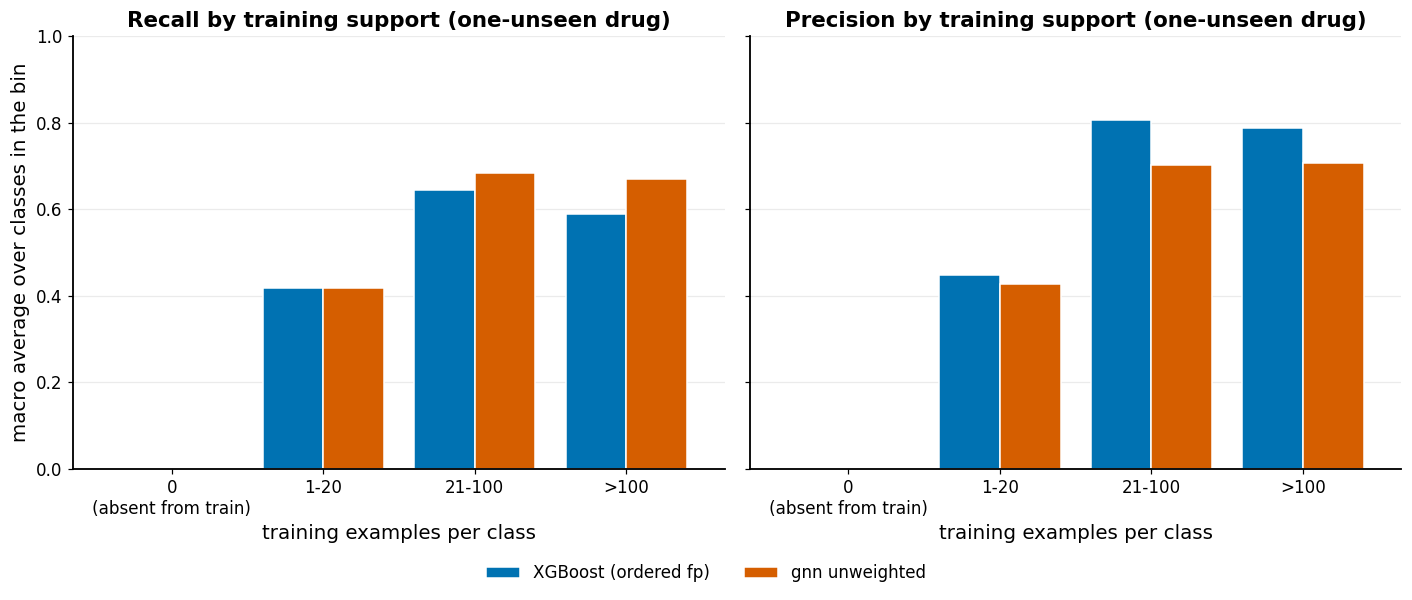

In [ ]:
T = pd.read_csv(OUT / 'tables' / 'tails_final.csv')
T = T[T.label.isin([e['label'] for e in ENTS])]                      # frozen finalists only
T1 = T[T.protocol == 'one-unseen-drug']
order = ['0 (absent from train)'] + [(f'{lo}-{hi}' if hi < 10**8 else f'>{lo - 1}') for lo, hi in CFG['TAIL_BINS']]
agg = T1.groupby(['label', 'bin'])[['n_classes_with_test_support', 'n_test', 'true_share', 'pred_share', 'macro_f1', 'macro_recall', 'macro_precision', 'micro_recall']].mean()

print('=== PERFORMANCE BY TRAINING-SUPPORT BIN (ONE-UNSEEN-DRUG) ===')
display(agg.round(3))
agg.to_csv(OUT / 'tables' / 'tail_by_support_bin.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
labels_ = sorted(T1.label.unique())
pal = [POSTER_COLORS[c] for c in ('blue', 'orange', 'green', 'purple', 'gold')][:len(labels_)]
plotted = []
for ax, met, name_ in zip(axes, ['macro_recall', 'macro_precision'], ['Recall', 'Precision']):
    pv = T1.groupby(['bin', 'label'])[met].mean().unstack('label').reindex(order)[labels_]
    pv.plot.bar(ax=ax, rot=0, width=0.8, color=pal, edgecolor='white', legend=False)
    ax.set_title(f'{name_} by training support (one-unseen drug)'); ax.set_xlabel('training examples per class'); ax.set_ylim(0, 1)
    ax.grid(axis='x', visible=False)
    ax.set_xticklabels([t.replace(' (', '\n(') for t in pv.index])
    plotted.append(pv.rename_axis('bin').reset_index().melt(id_vars='bin', var_name='label', value_name='value').assign(metric=met))
axes[0].set_ylabel('macro average over classes in the bin')
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=len(labels_), bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(); save_fig(fig, 'tail_by_support_bin', pd.concat(plotted, ignore_index=True))


### 10.3 Imbalance ablation on the test protocols (development partition)
The validation version, over all partitions, is in section 8; this is the same comparison on the test rows.

In [ ]:
A = R[(R.split == DEV) & (R.label.str.startswith(FROZEN['neural']))][['protocol', 'label', 'accuracy', 'macro_f1_all', 'macro_f1_supported', 'macro_recall_supported', 'top3', 'top5']]
A.to_csv(OUT / 'tables' / 'ablation_imbalance_test_dev_partition.csv', index=False); display(A.round(4))

,protocol,label,accuracy,macro_f1_all,macro_f1_supported,macro_recall_supported,top3,top5
2,one-unseen-drug,gnn unweighted,0.6865,0.5776,0.5914,0.6185,0.8754,0.9265
3,two-unseen-drug,gnn unweighted,0.4466,0.1424,0.2783,0.2831,0.6572,0.7644


### 10.4 Per-class table and split diagram

In [ ]:
tre = [e for e in ENTS if e['model'] == FROZEN['neural']][-1]
z = np.load(OUT / 'preds' / f'{DEV}__{slug(tre["label"])}__one_unseen.npz')
tp, true, pc, prec, rec, f1 = macro_stats(z['y'], z['pred'], K)
pc_tab = pd.DataFrame(dict(class_idx=np.arange(K), original_label=LABELS, train_count=z['train_counts'], test_support=true.astype(int),
                           predicted=pc.astype(int), precision=prec, recall=rec, f1=f1))
pc_tab.to_csv(OUT / 'tables' / 'per_class_one_unseen_dev.csv', index=False); display(pc_tab.sort_values('train_count').head(15).round(3))

,class_idx,original_label,train_count,test_support,predicted,precision,recall,f1
42,42,43,0,2,0,0.00,0.00,0.000
27,27,28,1,0,0,0.00,0.00,0.000
61,61,62,1,8,0,0.00,0.00,0.000
34,34,35,3,47,0,0.00,0.00,0.000
41,41,42,4,2,9,0.00,0.00,0.000
25,25,26,4,1,0,0.00,0.00,0.000
51,51,52,5,5,0,0.00,0.00,0.000
0,0,1,9,0,0,0.00,0.00,0.000
43,43,44,10,2,0,0.00,0.00,0.000
40,40,41,11,2,1,0.00,0.00,0.000


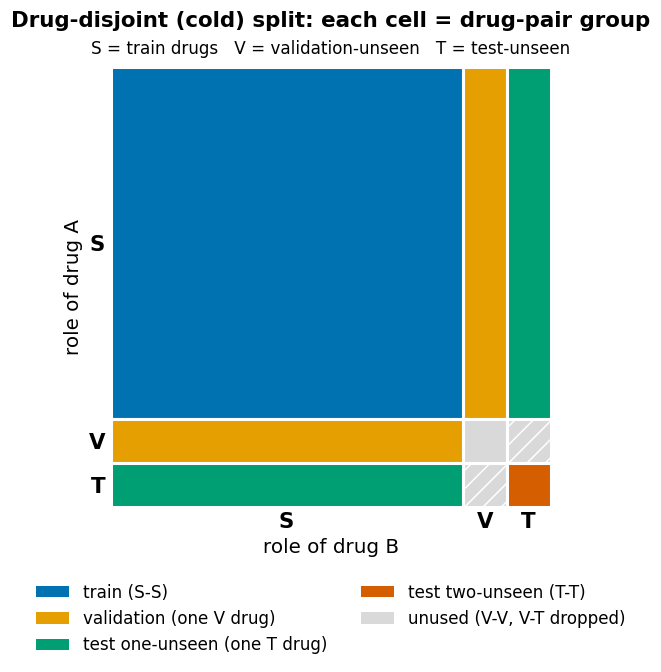

artifacts in /content/drive/MyDrive/ddi_poster/full_finale/figs and /content/drive/MyDrive/ddi_poster/full_finale/tables


In [ ]:
def draw_split_diagram(stem):
    tf, vf = CFG['COLD_TEST_DRUG_FRAC'], CFG['COLD_VAL_DRUG_FRAC']; sf = 1 - tf - vf
    edges = [0, sf, sf + vf, 1.0]; names = ['S: train drugs', 'V: validation-unseen', 'T: test-unseen']
    C = POSTER_COLORS
    col = {(0, 0): C['blue'], (0, 1): C['gold'], (1, 0): C['gold'], (0, 2): C['green'], (2, 0): C['green'], (2, 2): C['orange']}
    use = {(0, 0): 'train (S-S)', (0, 1): 'validation (one V drug)', (1, 0): 'validation (one V drug)',
           (0, 2): 'test one-unseen (one T drug)', (2, 0): 'test one-unseen (one T drug)', (2, 2): 'test two-unseen (T-T)'}
    role = SPLITS[DEV]['role']; ra, rb = role[DF_A], role[DF_B]
    fig, ax = plt.subplots(figsize=(7.2, 6.4)); cells = []
    for i in range(3):
        for j in range(3):
            ax.add_patch(plt.Rectangle((edges[j], 1 - edges[i + 1]), edges[j + 1] - edges[j], edges[i + 1] - edges[i],
                                       fc=col.get((i, j), '#d9d9d9'), ec='white', lw=2, hatch='//' if (i, j) in [(1, 2), (2, 1)] else None))
            cells.append(dict(drug_A_role=names[i], drug_B_role=names[j], used_as=use.get((i, j), 'unused (V-V, V-T dropped)'),
                              area_fraction=(edges[i + 1] - edges[i]) * (edges[j + 1] - edges[j]),
                              n_rows_in_dev_partition=int(((ra == i) & (rb == j)).sum())))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_xticks([(edges[k] + edges[k + 1]) / 2 for k in range(3)]); ax.set_xticklabels(['S', 'V', 'T'], fontsize=14, fontweight='bold')
    ax.set_yticks([1 - (edges[k] + edges[k + 1]) / 2 for k in range(3)]); ax.set_yticklabels(['S', 'V', 'T'], fontsize=14, fontweight='bold')
    ax.set_xlabel('role of drug B'); ax.set_ylabel('role of drug A')
    ax.text(0.5, 1.02, 'S = train drugs   V = validation-unseen   T = test-unseen', transform=ax.transAxes, ha='center', va='bottom', fontsize=11)
    ax.tick_params(length=0)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(fc=C['blue'], label='train (S-S)'), Patch(fc=C['gold'], label='validation (one V drug)'),
                       Patch(fc=C['green'], label='test one-unseen (one T drug)'), Patch(fc=C['orange'], label='test two-unseen (T-T)'),
                       Patch(fc='#d9d9d9', label='unused (V-V, V-T dropped)')], loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=11)
    ax.set_title('Drug-disjoint (cold) split: each cell = drug-pair group', pad=26)
    fig.tight_layout(); save_fig(fig, stem, pd.DataFrame(cells))
draw_split_diagram('cold_split_diagram')
print('artifacts in', OUT / 'figs', 'and', OUT / 'tables')


### 10.5 Paired cluster-bootstrap intervals

How much of a "neural beats XGBoost" gap could be luck in which drugs were held out? Test pairs that share the same held-out drug are correlated, so the bootstrap resamples **held-out drugs (identity groups)**, not rows, and compares the two models **on the same resample** (paired).

- Scope: one-unseen-drug test, conditional on the training drugs; not a temporal or external validation.
- "Supported labels" keeps the original test's label set fixed while resampling; "all 86 labels" uses every label.
- An interval that includes 0 means the data cannot separate the two models on that partition. It is not a significance test across partitions.
- Two-unseen-drug pairs are not bootstrapped (too few, and clusters overlap).

In [ ]:
def paired_cluster_bootstrap(split_key, label_a, label_b, test_set='one_unseen', repeats=None, seed=None):
    """Difference in macro-F1 (A minus B) with a 95% interval, resampling held-out identity groups."""
    repeats = repeats or CFG['BOOTSTRAP_REPEATS']; seed = CFG['BOOTSTRAP_SEED'] if seed is None else seed
    za = np.load(OUT / 'preds' / f'{split_key}__{slug(label_a)}__{test_set}.npz')
    zb = np.load(OUT / 'preds' / f'{split_key}__{slug(label_b)}__{test_set}.npz')
    assert np.array_equal(za['rows'], zb['rows']) and np.array_equal(za['y'], zb['y']), 'models were not evaluated on the same rows'
    rows, y = za['rows'], za['y']; sp = SPLITS[split_key]
    a, b = DF_A[rows], DF_B[rows]
    held_out_drug = np.where(sp['role'][a] == 2, a, b)                # the test drug in each pair
    cluster = sp['group'][held_out_drug]
    ta, pa, tpa = cluster_matrices(y, za['pred'], cluster)
    tb, pb, tpb = cluster_matrices(y, zb['pred'], cluster)
    G = ta.shape[0]
    rng = np.random.RandomState(seed)
    W = np.stack([np.bincount(rng.randint(0, G, G), minlength=G) for _ in range(repeats)]).astype(float)   # (repeats, G) resample weights
    one = np.ones((1, G))
    out = []
    for denom, classes in [('supported labels', np.where(ta.sum(0) > 0)[0]), ('all 86 labels', np.arange(K))]:
        obs = f1_from_counts(one @ tpa, one @ pa, one @ ta, classes)[0] - f1_from_counts(one @ tpb, one @ pb, one @ tb, classes)[0]
        d = f1_from_counts(W @ tpa, W @ pa, W @ ta, classes) - f1_from_counts(W @ tpb, W @ pb, W @ tb, classes)
        lo, hi = np.percentile(d, [2.5, 97.5])
        out.append(dict(split=split_key, A=label_a, B=label_b, f1_denominator=denom, observed_diff_A_minus_B=obs, ci95_low=lo, ci95_high=hi,
                        interval_includes_zero=bool(lo <= 0 <= hi), held_out_groups=G, repeats=repeats))
    return out

xgb_label = ENTS[0]['label']                                          # the XGBoost baseline
neural_labels = [e['label'] for e in ENTS if e['model'] == FROZEN['neural']]
comparisons = [(neural_labels[-1], xgb_label)]                        # frozen neural model vs XGBoost
if len(neural_labels) > 1: comparisons.append((neural_labels[-1], neural_labels[0]))    # treated vs unweighted (only if a treatment was frozen)

rows_bs = []
for sk in [f'cold{s}' for s in CFG['COLD_SEEDS']]:
    for la, lb in comparisons:
        if la != lb and (OUT / 'preds' / f'{sk}__{slug(la)}__one_unseen.npz').exists() and (OUT / 'preds' / f'{sk}__{slug(lb)}__one_unseen.npz').exists():
            rows_bs += paired_cluster_bootstrap(sk, la, lb)
BS = pd.DataFrame(rows_bs)
BS.to_csv(OUT / 'tables' / 'bootstrap_paired_intervals.csv', index=False)
print('Difference in macro-F1 on one-unseen-drug test, A minus B (positive = A ahead), 95% cluster-bootstrap interval:\n')
show(BS, digits=3)

Difference in macro-F1 on one-unseen-drug test, A minus B (positive = A ahead), 95% cluster-bootstrap interval:



,split,A,B,f1_denominator,observed_diff_A_minus_B,ci95_low,ci95_high,interval_includes_zero,held_out_groups,repeats
0,cold0,gnn unweighted,XGBoost (ordered fp),supported labels,-0.009,-0.036,0.036,True,164,1000
1,cold0,gnn unweighted,XGBoost (ordered fp),all 86 labels,-0.009,-0.035,0.036,True,164,1000
2,cold1,gnn unweighted,XGBoost (ordered fp),supported labels,-0.012,-0.048,0.013,True,164,1000
3,cold1,gnn unweighted,XGBoost (ordered fp),all 86 labels,-0.010,-0.041,0.011,True,164,1000
4,cold2,gnn unweighted,XGBoost (ordered fp),supported labels,0.030,-0.013,0.060,True,164,1000
5,cold2,gnn unweighted,XGBoost (ordered fp),all 86 labels,0.028,-0.012,0.056,True,164,1000


### 10.6 Results at a glance

In [ ]:
print('RESULTS AT A GLANCE  (mean ± sd over drug partitions; the sd is split sensitivity, not a significance test)\n')
for proto in ['known-drug', 'one-unseen-drug', 'two-unseen-drug']:
    if proto not in S.index.get_level_values('protocol'): continue
    sub = S.xs(proto, level='protocol').sort_values('macro_f1_all_mean', ascending=False)
    print(f'{proto}   ({int(sub.n_partitions.iloc[0])} partition(s))')
    for label, r in sub.iterrows():
        print(f'   {label:<30} accuracy {FMT(r.accuracy_mean, r.accuracy_sd):<15} F1(86) {FMT(r.macro_f1_all_mean, r.macro_f1_all_sd):<15} F1(supported) {FMT(r.macro_f1_supported_mean, r.macro_f1_supported_sd)}')
    print()

if 'one-unseen-drug' in S.index.get_level_values('protocol'):
    one = S.xs('one-unseen-drug', level='protocol')
    unstable = one[one.accuracy_sd > 0.05]
    if len(unstable):
        print('CHECK: large spread across partitions for:', ', '.join(unstable.index), '- see section 7 and the per-partition rows in results_final.csv.')
if len(BS):
    n_sep = int((~BS.interval_includes_zero).sum())
    print(f'Bootstrap: {n_sep} of {len(BS)} paired comparisons have an interval that excludes zero (see 10.5).')

RESULTS AT A GLANCE  (mean ± sd over drug partitions; the sd is split sensitivity, not a significance test)

known-drug   (1 partition(s))
   gnn unweighted                 accuracy 0.967           F1(86) 0.940           F1(supported) 0.940
   XGBoost (ordered fp)           accuracy 0.905           F1(86) 0.857           F1(supported) 0.857

one-unseen-drug   (3 partition(s))
   gnn unweighted                 accuracy 0.700 ± 0.016   F1(86) 0.566 ± 0.034   F1(supported) 0.609 ± 0.020
   XGBoost (ordered fp)           accuracy 0.666 ± 0.012   F1(86) 0.563 ± 0.024   F1(supported) 0.606 ± 0.010

two-unseen-drug   (3 partition(s))
   gnn unweighted                 accuracy 0.471 ± 0.022   F1(86) 0.147 ± 0.008   F1(supported) 0.309 ± 0.040
   XGBoost (ordered fp)           accuracy 0.447 ± 0.030   F1(86) 0.129 ± 0.005   F1(supported) 0.271 ± 0.030

Bootstrap: 0 of 6 paired comparisons have an interval that excludes zero (see 10.5).


##Notes and limits


- **Early stopping:** XGBoost stops on validation log-loss; neural models stop on validation macro-F1 over all 86 labels.
- **Identity groups** are structural (largest fragment, neutralised, no stereochemistry). They do not merge prodrugs, metabolites or other different molecules that behave alike.
- **Partitions overlap:** the three cold partitions are random splits of the same drugs, so they measure split sensitivity, not independent replication. The paired bootstrap covers the held-out-drug sampling within one partition only.
- **Interpretation:** a lower unseen-drug score is not a failure; it quantifies a harder task.
- **Reproducibility:** the raw-data hash, `audit.json`, `audit_identity.json`, split manifests and `frozen.json` (including the ablation summary) are written to the output folder. Record them together with the transformer checkpoint name.

## 11. Similarity-stratified evaluation

Does performance depend on how *similar* a held-out drug is to the drugs the models were trained on? This section answers that from the **saved test predictions of section 9**. Nothing is retrained, and no split, setting or earlier result is changed.

- **Similarity.** For every held-out drug: its highest Tanimoto similarity (the same Morgan bits the models use) to any training drug of that partition. One-unseen pairs use the held-out drug. Two-unseen pairs use both the lower and the mean of the two drugs' similarities.
- **Bins.** Fixed edges (0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0) and quartile edges taken from one-unseen *validation* pairs only. Neighbouring bins are merged until every bin has at least 200 (one-unseen) or 100 (two-unseen) pairs in every partition.
- **Metrics per bin.** Accuracy, macro-F1 over supported labels, macro-F1 over all 86 labels, and top-5 accuracy, as mean ± SD over the cold partitions. Top-3 is not available for subsets because the saved top-5 sets are unordered.
- **Model comparison.** 1,000 paired bootstrap draws that resample held-out identity groups (neural minus XGBoost, 95% percentile interval). Pooled draws must leave pairs in every partition. Two-unseen pairs are grouped by the lower-index drug's identity group, so dependence through the other drug is only partly captured.
- **High-similarity check.** Counts pairs with similarity ≥ 0.95 and identity twins in training for the grouped split versus a plain (ungrouped) drug split, and reports performance after dropping those pairs.

**Needs:** sections 0-10 run first (section 9 writes the predictions used here). **Writes:** tables to `tables/similarity/`, figures as `*_v2` PNG and PDF in `figs/`, plotted numbers in `tables/figure_data/`. Re-running overwrites only these files.

### 11.1 Setup, similarity and bootstrap helpers

In [ ]:
# ---- Settings ------------------------------------------------------------------------------------------------
SIM_DIR = OUT / 'tables' / 'similarity'; SIM_DIR.mkdir(parents=True, exist_ok=True)
XGB_LABEL, NN_LABEL = ENTS[0]['label'], ENTS[1]['label']       # frozen finalists: XGBoost, and the neural model trained without weights
MODELS = [XGB_LABEL, NN_LABEL]
NAMES = {XGB_LABEL: 'XGBoost', NN_LABEL: 'GNN + Morgan' if FROZEN['neural'] == 'gnn' else NN_LABEL}   # names shown in tables and figures
MEASURES = {'one_unseen': ['heldout'], 'two_unseen': ['sim_min', 'sim_mean']}   # similarity measure(s) used for each test protocol
MIN_PAIRS = {'one_unseen': 200, 'two_unseen': 100}             # every bin needs at least this many pairs in every partition
FIXED_EDGES = [0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
HIGH_SIM = 0.95                                                # pairs at or above this similarity are treated as near-duplicates
METRICS = ['accuracy', 'macro_f1_supported', 'macro_f1_all', 'top5']

# ---- Saved test predictions from section 9 -------------------------------------------------------------------
def pred_path(split_key, label, test_set):
    return OUT / 'preds' / f'{split_key}__{slug(label)}__{test_set}.npz'

SIM_PARTS = [sk for sk in (f'cold{s}' for s in CFG['COLD_SEEDS'])
             if all(pred_path(sk, m, t).exists() for m in MODELS for t in MEASURES)]
if not SIM_PARTS:
    raise FileNotFoundError('No saved test predictions found in preds/. Run sections 9.2-9.4 first.')
if len(SIM_PARTS) < len(CFG['COLD_SEEDS']):
    print(f'WARNING: predictions exist for {SIM_PARTS} only; means and SDs use these partitions.')

def load_pred(split_key, label, test_set):
    with np.load(pred_path(split_key, label, test_set)) as f:
        z = {k: f[k] for k in f.files}
    rows = SPLITS[split_key]['tests'][test_set]
    assert np.array_equal(z['rows'], rows) and np.array_equal(z['y'], DF_Y[rows]), 'saved predictions do not match the split'
    assert (z['train_counts'][z['pred']] > 0).all(), 'a class absent from training was predicted'
    return z

PRED = {(sk, m, t): load_pred(sk, m, t) for sk in SIM_PARTS for m in MODELS for t in MEASURES}

# ---- Similarity to the training drugs ------------------------------------------------------------------------
def train_drugs(sp):
    return np.unique(np.r_[DF_A[sp['train']], DF_B[sp['train']]])

def similarity_vector(sp):
    """Highest Tanimoto similarity (Morgan bits) between every drug and any training drug of split `sp`."""
    fp = FP_NP.astype(np.float32); tr = fp[train_drugs(sp)]
    inter = fp @ tr.T
    union = fp.sum(1)[:, None] + tr.sum(1)[None, :] - inter
    return (inter / np.maximum(union, 1)).max(axis=1)

SIM = {sk: similarity_vector(SPLITS[sk]) for sk in SIM_PARTS}

def held_out_drug(sp, rows):
    """The test drug of every one-unseen pair."""
    a, b = DF_A[rows], DF_B[rows]
    return np.where(sp['role'][a] == 2, a, b)

def pair_similarity(sk, test_set):
    """Similarity value(s) of every test pair of partition `sk`."""
    sp = SPLITS[sk]; rows = sp['tests'][test_set]; sim = SIM[sk]
    if test_set == 'one_unseen':
        return {'heldout': sim[held_out_drug(sp, rows)]}
    a, b = DF_A[rows], DF_B[rows]
    return {'sim_min': np.minimum(sim[a], sim[b]), 'sim_mean': (sim[a] + sim[b]) / 2}

def validation_quartile_edges():
    """Bin edges at the quartiles of one-unseen VALIDATION similarity (no test rows involved)."""
    vals = []
    for sk in SIM_PARTS:
        sp = SPLITS[sk]; a, b = DF_A[sp['val']], DF_B[sp['val']]
        vals.append(SIM[sk][np.where(sp['role'][a] == 1, a, b)])
    return np.unique(np.r_[0, np.quantile(np.concatenate(vals), [.25, .5, .75]), 1]).tolist()

# ---- Bins and per-bin metrics --------------------------------------------------------------------------------
def bin_ids(values, edges):
    """Bin index of every value; bins are [left, right) and the last one also includes 1.0."""
    return np.searchsorted(np.asarray(edges)[1:-1], values, side='right')

def merge_bins(values_by_split, edges, minimum):
    """Merge neighbouring bins (first short bin joins its right neighbour) until each holds >= `minimum` pairs in every partition."""
    edges = list(edges)
    while len(edges) > 2:
        counts = np.array([np.bincount(bin_ids(v, edges), minlength=len(edges) - 1) for v in values_by_split.values()])
        short = np.flatnonzero((counts < minimum).any(axis=0))
        if not len(short):
            break
        i = short[0]
        del edges[i + 1 if i < len(edges) - 2 else i]              # the last bin merges with its left neighbour instead
    return edges

def bin_metrics(z, keep):
    """Metrics of saved predictions `z` on the pairs selected by the boolean mask `keep`."""
    y, pred = z['y'][keep], z['pred'][keep]
    if len(y) == 0:
        return dict(n_pairs=0, n_supported_labels=0, **{m: np.nan for m in METRICS})
    tp, true, pc, prec, rec, f1 = macro_stats(y, pred, K); sup = true > 0
    return dict(n_pairs=len(y), n_supported_labels=int(sup.sum()), accuracy=float((y == pred).mean()),
                macro_f1_supported=float(f1[sup].mean()), macro_f1_all=float(f1.mean()),
                top5=float((z['top5'][keep] == y[:, None]).any(1).mean()))    # top-3 is not available: the saved top-5 sets are unordered

# ---- Paired identity-group bootstrap -------------------------------------------------------------------------
def pair_clusters(sk, rows, test_set):
    """Identity group that is resampled: the held-out drug's group (one-unseen) or the lower-index drug's group (two-unseen)."""
    sp = SPLITS[sk]; a, b = DF_A[rows], DF_B[rows]
    return sp['group'][held_out_drug(sp, rows) if test_set == 'one_unseen' else np.minimum(a, b)]

def similarity_bootstrap(parts):
    """95% bootstrap interval for (neural - XGBoost), resampling identity groups; both models are scored on the same draw.

    parts = [(split_key, y, neural_pred, xgb_pred, cluster), ...]. One entry gives a within-partition interval. Several entries
    give a pooled interval: each draw uses one set of group weights for every partition, and a draw that leaves any partition
    without pairs is redrawn (so the pooled interval is conditional on non-empty support in every partition)."""
    reps, rng = CFG['BOOTSTRAP_REPEATS'], np.random.RandomState(CFG['BOOTSTRAP_SEED'])
    union = np.unique(np.concatenate([p[4] for p in parts])); G = len(union)
    draw = lambda n: rng.multinomial(G, np.full(G, 1.0 / G), size=n).astype(float)     # how often each group is drawn
    member = np.stack([np.isin(union, p[4]) for p in parts], axis=1).astype(float)      # (groups, partitions)
    W = draw(reps); empty = (W @ member == 0).any(axis=1); tries = 0
    while empty.any():
        tries += 1
        if tries > 1000:
            raise RuntimeError('could not draw bootstrap samples with pairs in every partition')
        W[empty] = draw(int(empty.sum())); empty = (W @ member == 0).any(axis=1)

    obs = {m: [] for m in ('macro_f1_all', 'macro_f1_supported', 'accuracy')}; dif = {m: [] for m in obs}
    for _, y, p_nn, p_xgb, cl in parts:
        t, pn, tpn = cluster_matrices(y, p_nn, cl); _, px, tpx = cluster_matrices(y, p_xgb, cl)
        w = W[:, np.searchsorted(union, np.unique(cl))]              # draw weights of this partition's groups
        one = np.ones((1, t.shape[0]))
        for m, cls in (('macro_f1_all', np.arange(K)), ('macro_f1_supported', np.flatnonzero(t.sum(0) > 0))):
            obs[m].append(f1_from_counts(one @ tpn, one @ pn, one @ t, cls)[0] - f1_from_counts(one @ tpx, one @ px, one @ t, cls)[0])
            dif[m].append(f1_from_counts(w @ tpn, w @ pn, w @ t, cls) - f1_from_counts(w @ tpx, w @ px, w @ t, cls))
        obs['accuracy'].append((tpn.sum() - tpx.sum()) / t.sum())
        dif['accuracy'].append((w @ (tpn - tpx)).sum(axis=1) / (w @ t).sum(axis=1))
    out = []
    for m in obs:
        lo, hi = np.percentile(np.mean(dif[m], axis=0), [2.5, 97.5])   # pooled: every partition counts equally in each draw
        out.append(dict(split=parts[0][0] if len(parts) == 1 else 'pooled_cold', n_partitions=len(parts), metric=m,
                        observed_diff_nn_minus_xgb=float(np.mean(obs[m])), ci95_low=float(lo), ci95_high=float(hi),
                        interval_includes_zero=bool(lo <= 0 <= hi), held_out_groups=G, repeats=reps))
    return out

print(f'Ready: {NAMES[NN_LABEL]} vs {NAMES[XGB_LABEL]}, partitions {SIM_PARTS}, {CFG["BOOTSTRAP_REPEATS"]} bootstrap draws.')

Ready: GNN + Morgan vs XGBoost, partitions ['cold0', 'cold1', 'cold2'], 1000 bootstrap draws.


### 11.2 Metrics and bootstrap intervals per similarity bin

In [ ]:
QUARTILE_EDGES = validation_quartile_edges()
SCHEMES = {'fixed': FIXED_EDGES, 'validation_quartile': QUARTILE_EDGES}

detail, boot_rows, count_rows = [], [], []
for test_set, measures in MEASURES.items():
    for measure in measures:
        values = {sk: pair_similarity(sk, test_set)[measure] for sk in SIM_PARTS}       # similarity of every test pair, per partition
        for scheme, start_edges in SCHEMES.items():
            edges = merge_bins(values, start_edges, MIN_PAIRS[test_set])
            tag = dict(protocol=PROTO[test_set], test_set=test_set, similarity_measure=measure, scheme=scheme)
            print(f'{PROTO[test_set]:<16} {measure:<8} {scheme:<20} bin edges after merging:', [round(e, 3) for e in edges])
            for stage, e in (('initial', start_edges), ('merged', edges)):               # pair counts before and after merging
                for sk in SIM_PARTS:
                    for i, n in enumerate(np.bincount(bin_ids(values[sk], e), minlength=len(e) - 1)):
                        count_rows.append(dict(**tag, split=sk, stage=stage, bin=i, left=e[i], right=e[i + 1], n_pairs=int(n)))
            for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
                bin_tag = dict(**tag, bin=i, left=lo, right=hi, interval=f'{lo:.2f}–{hi:.2f}')
                parts = []
                for sk in SIM_PARTS:
                    keep = bin_ids(values[sk], edges) == i
                    zn, zx = PRED[sk, NN_LABEL, test_set], PRED[sk, XGB_LABEL, test_set]
                    for m in MODELS:
                        detail.append(dict(**bin_tag, split=sk, model=m, **bin_metrics(PRED[sk, m, test_set], keep)))
                    parts.append((sk, zn['y'][keep], zn['pred'][keep], zx['pred'][keep], pair_clusters(sk, SPLITS[sk]['tests'][test_set][keep], test_set)))
                for group in [[p] for p in parts] + ([parts] if len(parts) > 1 else []):   # each partition alone, then all pooled
                    if all(len(p[1]) for p in group):
                        boot_rows += [{**bin_tag, **r} for r in similarity_bootstrap(group)]

detail = pd.DataFrame(detail)
keys = ['protocol', 'test_set', 'similarity_measure', 'scheme', 'bin', 'left', 'right', 'interval', 'model']
cols = METRICS + ['n_pairs', 'n_supported_labels']
grp = detail.groupby(keys)
summary_tbl = (grp[cols].mean().add_suffix('_mean').join(grp[cols].std(ddof=1).add_suffix('_sd'))
               .join(grp['split'].nunique().rename('n_partitions')).reset_index())
boot_tbl = pd.DataFrame(boot_rows)

detail.to_csv(SIM_DIR / 'metrics_by_partition.csv', index=False)
summary_tbl.to_csv(SIM_DIR / 'metrics_summary.csv', index=False)
pd.DataFrame(count_rows).to_csv(SIM_DIR / 'bin_counts.csv', index=False)
boot_tbl.to_csv(SIM_DIR / 'bootstrap_nn_minus_xgb.csv', index=False)
print('\nSaved metrics_by_partition, metrics_summary, bin_counts and bootstrap_nn_minus_xgb to', SIM_DIR)

one-unseen-drug  heldout  fixed                bin edges after merging: [0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
one-unseen-drug  heldout  validation_quartile  bin edges after merging: [0.0, 0.333, 0.5, 0.667, 1.0]
two-unseen-drug  sim_min  fixed                bin edges after merging: [0, 0.3, 0.4, 0.5, 0.6, 1.0]
two-unseen-drug  sim_min  validation_quartile  bin edges after merging: [0.0, 0.333, 0.5, 0.667, 1.0]
two-unseen-drug  sim_mean fixed                bin edges after merging: [0, 0.4, 0.5, 0.6, 0.7, 1.0]
two-unseen-drug  sim_mean validation_quartile  bin edges after merging: [0.0, 0.333, 0.5, 0.667, 1.0]

Saved metrics_by_partition, metrics_summary, bin_counts and bootstrap_nn_minus_xgb to /content/drive/MyDrive/ddi_poster/full_finale/tables/similarity


### 11.3 Results tables

In [ ]:
# Fixed bins; two-unseen pairs are shown by their less-similar endpoint (sim_min)
fixed = summary_tbl[(summary_tbl.scheme == 'fixed') & summary_tbl.similarity_measure.isin(['heldout', 'sim_min'])]
fixed = fixed.sort_values(['test_set', 'left', 'model']).reset_index(drop=True)

def pct(metric):
    """'mean ± SD' in percent (just the mean if there is only one partition)."""
    return [f'{100 * m:.1f}' if pd.isna(s) else f'{100 * m:.1f} ± {100 * s:.1f}'
            for m, s in zip(fixed[metric + '_mean'], fixed[metric + '_sd'])]

poster_tbl = pd.DataFrame({'Protocol': fixed.protocol, 'Similarity bin': fixed.interval, 'Model': fixed.model.map(NAMES),
                           'Mean pairs': fixed.n_pairs_mean.round(0).astype(int),
                           'Accuracy (%)': pct('accuracy'), 'Macro-F1, supported (%)': pct('macro_f1_supported'),
                           'Macro-F1, all 86 (%)': pct('macro_f1_all'), 'Top-5 (%)': pct('top5')})
poster_tbl.to_csv(SIM_DIR / 'summary_table_fixed_bins.csv', index=False)
print(f'Mean ± SD over {len(SIM_PARTS)} cold partition(s). Macro-F1 over all 86 labels counts labels absent from a bin as 0, so it is low and noisy in sparse bins.')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(poster_tbl)

print('\nPaired bootstrap, pooled over partitions: neural minus XGBoost (positive = neural ahead), 95% interval, fixed bins')
pooled = boot_tbl[(boot_tbl.n_partitions == len(SIM_PARTS)) & (boot_tbl.scheme == 'fixed') & boot_tbl.similarity_measure.isin(['heldout', 'sim_min'])]
pooled = pooled[['protocol', 'interval', 'metric', 'observed_diff_nn_minus_xgb', 'ci95_low', 'ci95_high', 'interval_includes_zero']]
show(pooled.sort_values(['protocol', 'metric']).reset_index(drop=True), digits=3)

Mean ± SD over 3 cold partition(s). Macro-F1 over all 86 labels counts labels absent from a bin as 0, so it is low and noisy in sparse bins.


,Protocol,Similarity bin,Model,Mean pairs,Accuracy (%),"Macro-F1, supported (%)","Macro-F1, all 86 (%)",Top-5 (%)
0,one-unseen-drug,0.00–0.30,XGBoost,5339,49.5 ± 1.9,38.0 ± 1.4,18.8 ± 2.1,90.2 ± 4.2
1,one-unseen-drug,0.00–0.30,GNN + Morgan,5339,48.4 ± 5.2,38.6 ± 2.9,19.0 ± 1.4,82.6 ± 5.2
2,one-unseen-drug,0.30–0.40,XGBoost,5479,56.8 ± 3.9,46.6 ± 3.6,28.6 ± 2.6,90.9 ± 2.1
3,one-unseen-drug,0.30–0.40,GNN + Morgan,5479,60.8 ± 0.9,49.1 ± 4.1,30.3 ± 4.1,89.3 ± 3.2
4,one-unseen-drug,0.40–0.50,XGBoost,4354,64.4 ± 6.7,64.9 ± 9.4,37.4 ± 6.6,93.7 ± 3.4
5,one-unseen-drug,0.40–0.50,GNN + Morgan,4354,71.3 ± 5.5,65.1 ± 2.3,37.6 ± 5.1,95.2 ± 3.8
6,one-unseen-drug,0.50–0.60,XGBoost,5802,75.0 ± 2.4,71.3 ± 1.9,47.3 ± 3.8,97.2 ± 1.2
7,one-unseen-drug,0.50–0.60,GNN + Morgan,5802,81.2 ± 3.4,79.2 ± 4.3,52.5 ± 3.6,98.0 ± 1.1
8,one-unseen-drug,0.60–0.70,XGBoost,4308,75.1 ± 4.7,76.8 ± 3.9,47.7 ± 4.6,93.2 ± 2.2
9,one-unseen-drug,0.60–0.70,GNN + Morgan,4308,77.9 ± 4.8,75.7 ± 5.2,47.0 ± 5.0,94.6 ± 4.4



Paired bootstrap, pooled over partitions: neural minus XGBoost (positive = neural ahead), 95% interval, fixed bins


,protocol,interval,metric,observed_diff_nn_minus_xgb,ci95_low,ci95_high,interval_includes_zero
0,one-unseen-drug,0.00–0.30,accuracy,-0.010,-0.063,0.053,True
1,one-unseen-drug,0.30–0.40,accuracy,0.039,-0.005,0.081,True
2,one-unseen-drug,0.40–0.50,accuracy,0.068,-0.005,0.146,True
3,one-unseen-drug,0.50–0.60,accuracy,0.062,0.032,0.095,False
4,one-unseen-drug,0.60–0.70,accuracy,0.028,-0.008,0.066,True
5,one-unseen-drug,0.70–0.80,accuracy,0.030,0.006,0.051,False
6,one-unseen-drug,0.80–1.00,accuracy,0.003,-0.044,0.042,True
7,one-unseen-drug,0.00–0.30,macro_f1_all,0.002,-0.019,0.020,True
8,one-unseen-drug,0.30–0.40,macro_f1_all,0.017,-0.011,0.035,True
9,one-unseen-drug,0.40–0.50,macro_f1_all,0.002,-0.017,0.027,True


### 11.4 High-similarity pairs and identity twins

In [ ]:
def max_endpoint_sim(sp, sim, rows, test_set):
    """Similarity used for the >= 0.95 rule: the held-out drug (one-unseen) or the more similar endpoint (two-unseen)."""
    a, b = DF_A[rows], DF_B[rows]
    return sim[held_out_drug(sp, rows)] if test_set == 'one_unseen' else np.maximum(sim[a], sim[b])

# (a) High-similarity pairs and identity twins: grouped split (used) versus a plain drug-level split (reference, audit only)
audit_rows = []
for sk in SIM_PARTS:
    seed = int(sk.replace('cold', ''))
    plain = make_cold_split(df, np.arange(len(CANON)), seed, CFG['COLD_VAL_DRUG_FRAC'], CFG['COLD_TEST_DRUG_FRAC'])
    for kind, sp in (('grouped (used)', SPLITS[sk]), ('ungrouped (reference)', plain)):
        sim = SIM[sk] if kind.startswith('grouped') else similarity_vector(sp)
        twin = np.isin(DRUG_GROUP, DRUG_GROUP[train_drugs(sp)]) & (sp['role'] > 0)      # held-out drug with a structural twin in training
        for test_set in MEASURES:
            rows = sp['tests'][test_set]; a, b = DF_A[rows], DF_B[rows]
            drugs = np.unique(np.r_[a, b]); drugs = drugs[sp['role'][drugs] == 2]
            pair_twin = twin[held_out_drug(sp, rows)] if test_set == 'one_unseen' else twin[a] | twin[b]
            high = max_endpoint_sim(sp, sim, rows, test_set) >= HIGH_SIM
            audit_rows.append(dict(split=sk, split_type=kind, protocol=PROTO[test_set], n_pairs=len(rows),
                                   pairs_sim_ge095=int(high.sum()), pct_pairs_sim_ge095=100 * float(high.mean()),
                                   test_drugs=len(drugs), test_drugs_with_identity_twin_in_train=int(twin[drugs].sum()),
                                   pairs_with_identity_twin=int(pair_twin.sum())))
leak = pd.DataFrame(audit_rows); leak.to_csv(SIM_DIR / 'high_similarity_pair_counts.csv', index=False)
print('Test pairs with similarity >= 0.95 and identity twins in training (per partition):')
show(leak, digits=2)

# (b) Grouped-model performance with and without the >= 0.95 pairs
excl_rows = []
for sk in SIM_PARTS:
    sp = SPLITS[sk]
    for test_set in MEASURES:
        rows = sp['tests'][test_set]; keep = max_endpoint_sim(sp, SIM[sk], rows, test_set) < HIGH_SIM
        for m in MODELS:
            z = PRED[sk, m, test_set]; before, after = bin_metrics(z, np.ones(len(rows), bool)), bin_metrics(z, keep)
            excl_rows.append(dict(split=sk, protocol=PROTO[test_set], model=NAMES[m], n_before=before['n_pairs'], n_after=after['n_pairs'],
                                  **{f'{k}_before': before[k] for k in METRICS}, **{f'{k}_after': after[k] for k in METRICS},
                                  **{f'{k}_change': after[k] - before[k] for k in METRICS}))
excl = pd.DataFrame(excl_rows); excl.to_csv(SIM_DIR / 'performance_excluding_ge095_by_partition.csv', index=False)
excl_mean = excl.drop(columns='split').groupby(['protocol', 'model']).mean().reset_index()
excl_mean.to_csv(SIM_DIR / 'performance_excluding_ge095_summary.csv', index=False)
print('\nPerformance before / after dropping pairs with similarity >= 0.95 (mean over partitions):')
show(excl_mean[['protocol', 'model', 'n_before', 'n_after'] + [f'{k}_{s}' for k in ('accuracy', 'macro_f1_supported') for s in ('before', 'after', 'change')]], digits=4)

Test pairs with similarity >= 0.95 and identity twins in training (per partition):


,split,split_type,protocol,n_pairs,pairs_sim_ge095,pct_pairs_sim_ge095,test_drugs,test_drugs_with_identity_twin_in_train,pairs_with_identity_twin
0,cold0,grouped (used),one-unseen-drug,32193,89,0.28,171,0,0
1,cold0,grouped (used),two-unseen-drug,2071,10,0.48,152,0,0
2,cold0,ungrouped (reference),one-unseen-drug,29774,1279,4.30,169,12,1807
3,cold0,ungrouped (reference),two-unseen-drug,1782,164,9.20,147,9,215
4,cold1,grouped (used),one-unseen-drug,32162,109,0.34,170,0,0
5,cold1,grouped (used),two-unseen-drug,2126,22,1.03,158,0,0
6,cold1,ungrouped (reference),one-unseen-drug,33869,821,2.42,170,9,1316
7,cold1,ungrouped (reference),two-unseen-drug,2432,130,5.35,154,7,208
8,cold2,grouped (used),one-unseen-drug,31501,0,0.00,170,0,0
9,cold2,grouped (used),two-unseen-drug,1970,0,0.00,155,0,0



Performance before / after dropping pairs with similarity >= 0.95 (mean over partitions):


,protocol,model,n_before,n_after,accuracy_before,accuracy_after,accuracy_change,macro_f1_supported_before,macro_f1_supported_after,macro_f1_supported_change
0,one-unseen-drug,GNN + Morgan,31952.0000,31886.0,0.7000,0.6993,-0.0006,0.6090,0.6093,0.0003
1,one-unseen-drug,XGBoost,31952.0000,31886.0,0.6663,0.6657,-0.0007,0.6060,0.6058,-0.0002
2,two-unseen-drug,GNN + Morgan,2055.6667,2045.0,0.4715,0.4696,-0.0019,0.3085,0.2948,-0.0137
3,two-unseen-drug,XGBoost,2055.6667,2045.0,0.4466,0.4446,-0.0020,0.2706,0.2545,-0.0161


### 11.5 Figures

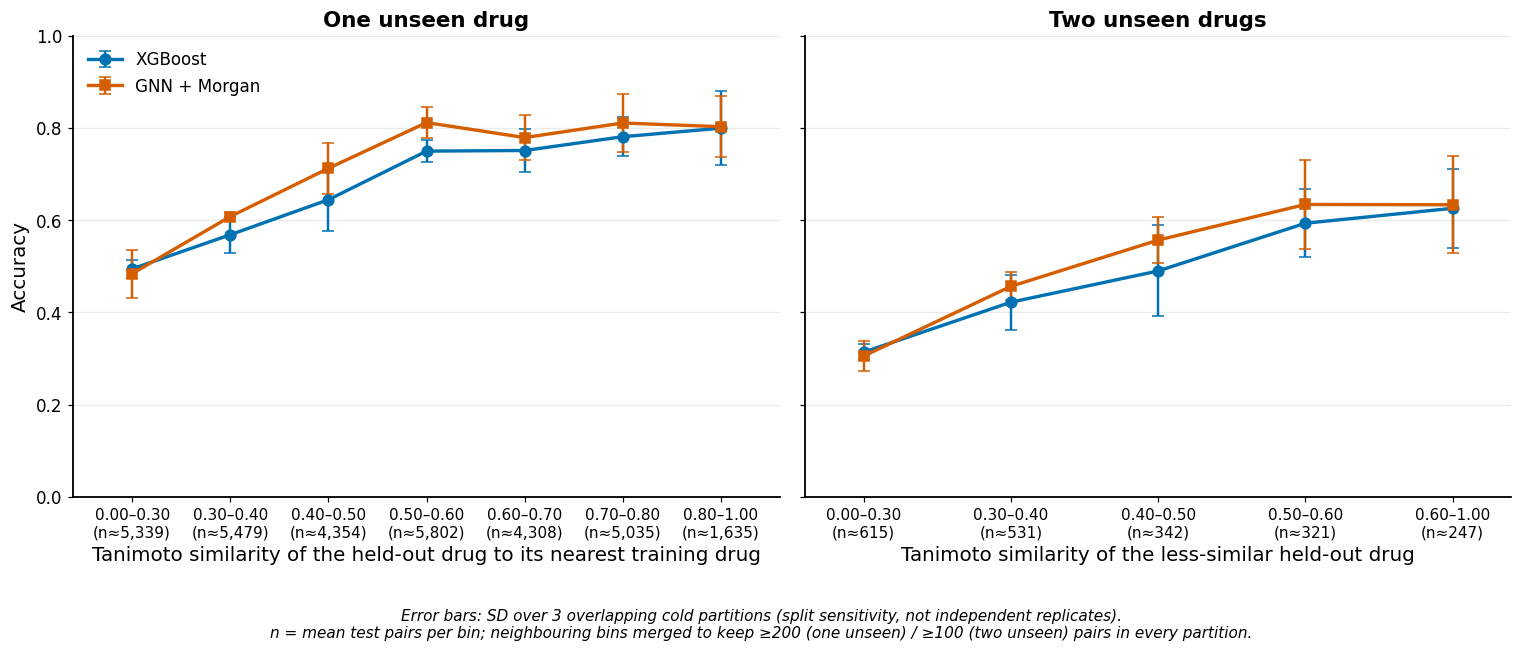

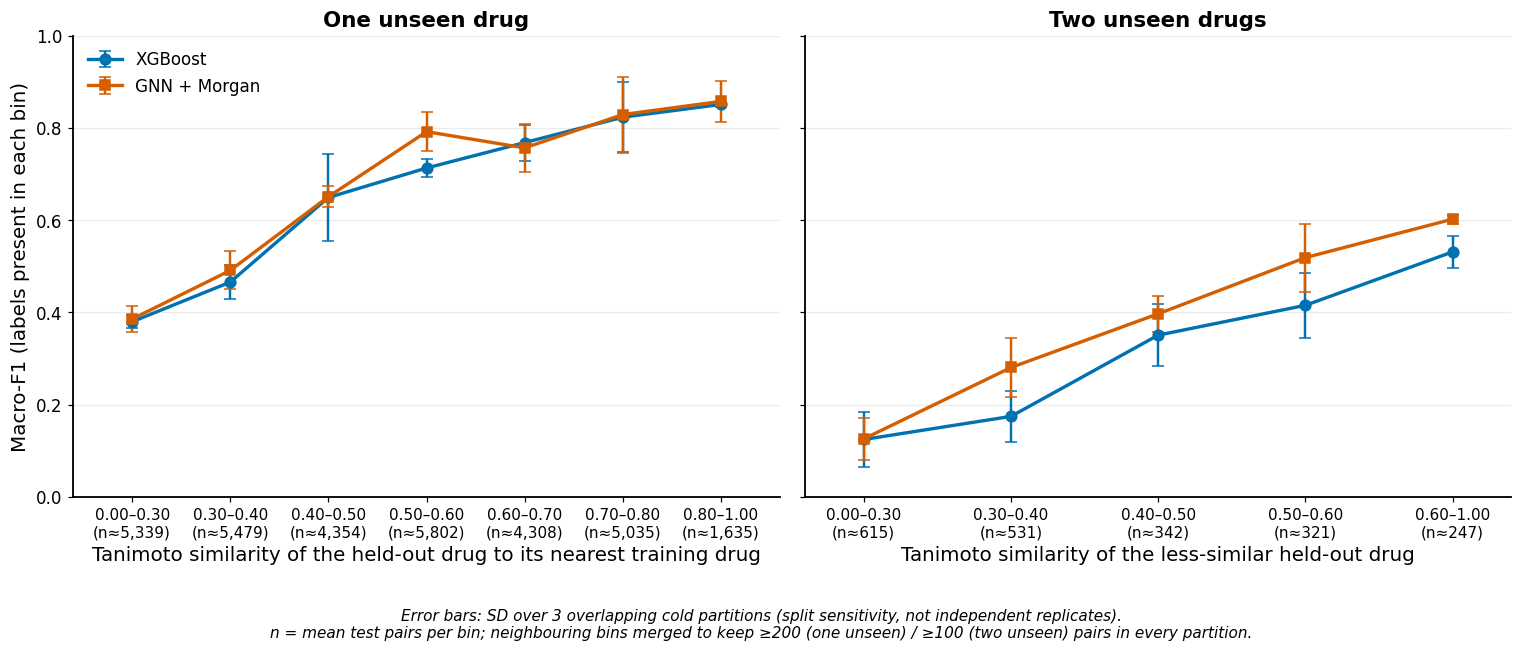

In [ ]:
def plot_similarity(metric, ylabel, stem):
    """Mean ± SD (over cold partitions) of `metric` against held-out-drug similarity, for both models."""
    panels = [('one_unseen', 'heldout', 'One unseen drug', 'of the held-out drug to its nearest training drug'),
              ('two_unseen', 'sim_min', 'Two unseen drugs', 'of the less-similar held-out drug')]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharey=True); plotted = []
    for ax, (test_set, measure, title, xlabel) in zip(axes, panels):
        sub = fixed[(fixed.test_set == test_set) & (fixed.similarity_measure == measure)]
        for model, color, marker in zip(MODELS, (POSTER_COLORS['blue'], POSTER_COLORS['orange']), ('o', 's')):
            r = sub[sub.model == model].sort_values('left'); x = np.arange(len(r))
            ax.errorbar(x, r[metric + '_mean'], yerr=r[metric + '_sd'].fillna(0), color=color, marker=marker,
                        capsize=4, elinewidth=1.6, label=NAMES[model])
            plotted.append(r.assign(panel=title)[['panel', 'model', 'interval', 'left', 'right', 'n_pairs_mean', metric + '_mean', metric + '_sd']])
        ax.margins(x=0.1); ax.set_xticks(x); ax.set_xticklabels([f'{iv}\n(n≈{n:,.0f})' for iv, n in zip(r.interval, r.n_pairs_mean)], fontsize=10)
        ax.set_xlabel('Tanimoto similarity ' + xlabel); ax.set_title(title); ax.set_ylim(0, 1)
    axes[0].set_ylabel(ylabel); axes[0].legend(loc='upper left')
    fig.text(0.5, -0.04, f'Error bars: SD over {len(SIM_PARTS)} overlapping cold partitions (split sensitivity, not independent replicates).\n'
             'n = mean test pairs per bin; neighbouring bins merged to keep ≥200 (one unseen) / ≥100 (two unseen) pairs in every partition.',
             ha='center', va='top', fontsize=10, style='italic')
    fig.tight_layout(); save_fig(fig, stem, pd.concat(plotted, ignore_index=True))

plot_similarity('accuracy', 'Accuracy', 'similarity_accuracy_v2')
plot_similarity('macro_f1_supported', 'Macro-F1 (labels present in each bin)', 'similarity_macro_f1_v2')

### 11.6 Key numbers

In [ ]:
lines = [f'Means and SDs use {len(SIM_PARTS)} cold partition(s) ({", ".join(SIM_PARTS)}); the partitions overlap, so the SD describes split sensitivity only.']
for test_set, measure in [('one_unseen', 'heldout'), ('two_unseen', 'sim_min')]:
    for m in MODELS:
        r = fixed[(fixed.test_set == test_set) & (fixed.model == m) & (fixed.similarity_measure == measure)]
        lines.append(f'{PROTO[test_set]}, {NAMES[m]}: accuracy {r.accuracy_mean.min():.3f}-{r.accuracy_mean.max():.3f} and '
                     f'supported-label macro-F1 {r.macro_f1_supported_mean.min():.3f}-{r.macro_f1_supported_mean.max():.3f} across the merged fixed bins.')
b = boot_tbl[(boot_tbl.n_partitions == len(SIM_PARTS)) & (boot_tbl.scheme == 'fixed') & (boot_tbl.metric == 'macro_f1_supported')
             & boot_tbl.similarity_measure.isin(['heldout', 'sim_min'])]
lines.append(f'Paired bootstrap ({CFG["BOOTSTRAP_REPEATS"]} draws, {NAMES[NN_LABEL]} minus {NAMES[XGB_LABEL]}, supported-label macro-F1): '
             f'{int((~b.interval_includes_zero).sum())} of {len(b)} fixed bins have a 95% interval that excludes zero '
             '(pointwise, conditional on non-empty partitions; two-unseen clustering is approximate).')
for (kind, proto), r in leak.groupby(['split_type', 'protocol'])[['pairs_sim_ge095', 'pairs_with_identity_twin']].sum().iterrows():
    lines.append(f'{kind}, {proto}: {int(r.pairs_sim_ge095):,} test pairs with similarity ≥{HIGH_SIM} and {int(r.pairs_with_identity_twin):,} '
                 'with an identity twin in training, summed over partitions (partitions overlap, so these are not unique pairs).')
for _, r in excl_mean[excl_mean.model == NAMES[NN_LABEL]].iterrows():
    lines.append(f'{r.protocol}, {r.model}, excluding pairs ≥{HIGH_SIM}: accuracy {r.accuracy_change:+.4f}, supported-label macro-F1 {r.macro_f1_supported_change:+.4f} on average.')

text = '\n'.join('- ' + l for l in lines) + '\n'
(SIM_DIR / 'findings.md').write_text(text, encoding='utf-8')
from IPython.display import Markdown
display(Markdown(text))

- Means and SDs use 3 cold partition(s) (cold0, cold1, cold2); the partitions overlap, so the SD describes split sensitivity only.
- one-unseen-drug, XGBoost: accuracy 0.495-0.800 and supported-label macro-F1 0.380-0.851 across the merged fixed bins.
- one-unseen-drug, GNN + Morgan: accuracy 0.484-0.812 and supported-label macro-F1 0.386-0.858 across the merged fixed bins.
- two-unseen-drug, XGBoost: accuracy 0.314-0.626 and supported-label macro-F1 0.124-0.531 across the merged fixed bins.
- two-unseen-drug, GNN + Morgan: accuracy 0.305-0.634 and supported-label macro-F1 0.126-0.602 across the merged fixed bins.
- Paired bootstrap (1000 draws, GNN + Morgan minus XGBoost, supported-label macro-F1): 5 of 12 fixed bins have a 95% interval that excludes zero (pointwise, conditional on non-empty partitions; two-unseen clustering is approximate).
- grouped (used), one-unseen-drug: 198 test pairs with similarity ≥0.95 and 0 with an identity twin in training, summed over partitions (partitions overlap, so these are not unique pairs).
- grouped (used), two-unseen-drug: 32 test pairs with similarity ≥0.95 and 0 with an identity twin in training, summed over partitions (partitions overlap, so these are not unique pairs).
- ungrouped (reference), one-unseen-drug: 2,424 test pairs with similarity ≥0.95 and 3,846 with an identity twin in training, summed over partitions (partitions overlap, so these are not unique pairs).
- ungrouped (reference), two-unseen-drug: 346 test pairs with similarity ≥0.95 and 519 with an identity twin in training, summed over partitions (partitions overlap, so these are not unique pairs).
- one-unseen-drug, GNN + Morgan, excluding pairs ≥0.95: accuracy -0.0006, supported-label macro-F1 +0.0003 on average.
- two-unseen-drug, GNN + Morgan, excluding pairs ≥0.95: accuracy -0.0019, supported-label macro-F1 -0.0137 on average.


### 11.7 Reading the outputs

- `metrics_by_partition.csv` and `metrics_summary.csv` hold every metric per bin, per partition and as mean/SD; `bin_counts.csv` lists pair counts before and after merging bins.
- `summary_table_fixed_bins.csv` is the poster-ready table (mean ± SD in percent).
- `bootstrap_nn_minus_xgb.csv` gives the paired differences with 95% intervals, per partition and pooled. An interval that includes 0 means the data cannot separate the two models in that bin; it is not a significance test.
- `high_similarity_pair_counts.csv` and `performance_excluding_ge095_*.csv` show how much of the test set has a near-duplicate in training and how the grouped models fare without it.
- Supported-label F1 uses only labels present in the bin. All-86 F1 stays in the tables, but it is low and noisy in sparse bins.
- `findings.md` collects the key measured numbers of this run.